<a href="https://www.kaggle.com/code/lalit7881/indian-e-commerce-sales-customer-eda-100?scriptVersionId=344522954" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/products.csv
/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/customer_reviews.csv
/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/data_dictionary.csv
/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/generate_dataset.py
/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/marketing_campaigns.csv
/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/README.md
/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/dataset_validation_report.csv
/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/shipments.csv
/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/order_items.csv
/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-c

## Loading dataset

In [2]:
# 1. Load Datasets
orders = pd.read_csv('/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/orders.csv')
order_items = pd.read_csv('/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/order_items.csv')
customers = pd.read_csv('/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/customers.csv')
products = pd.read_csv('/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/products.csv')
payments = pd.read_csv('/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/payments.csv')
shipments = pd.read_csv('/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/shipments.csv')
returns = pd.read_csv('/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/returns.csv')
reviews = pd.read_csv('/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/customer_reviews.csv')
marketing = pd.read_csv('/kaggle/input/datasets/shiyalkishan01/indian-e-commerce-sales-and-customer-analytics/marketing_campaigns.csv')

In [3]:
df = order_items.merge(orders, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left', suffixes=('', '_cust'))
df = df.merge(products, on='product_id', how='left', suffixes=('', '_prod'))
df = df.merge(payments, on='order_id', how='left', suffixes=('', '_pay'))
df = df.merge(shipments, on='order_id', how='left', suffixes=('', '_ship'))
df = df.merge(returns, on=['order_id', 'product_id'], how='left', suffixes=('', '_ret'))


In [4]:
date_columns = ['order_date', 'customer_signup_date', 'dispatch_date', 'expected_delivery_date', 'actual_delivery_date', 'return_date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [5]:
df['is_returned'] = df['return_id'].notnull().astype(int)

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

In [8]:
print(df.head(5))

  order_item_id    order_id product_id  quantity  unit_price  \
0    OI10000000  ORD1000000  PROD10347         4       150.0   
1    OI10000001  ORD1000000  PROD10510         1      1150.0   
2    OI10000002  ORD1000000  PROD10305         2       960.0   
3    OI10000003  ORD1000000  PROD10092         4       920.0   
4    OI10000004  ORD1000000  PROD10417         3      2640.0   

   discount_percentage_x  item_revenue  item_cost  profit customer_id  ...  \
0                    6.5         561.0     515.92   45.08  CUST103868  ...   
1                    5.0        1092.5     752.18  340.32  CUST103868  ...   
2                    8.0        1766.4    1217.66  548.74  CUST103868  ...   
3                    5.0        3496.0    3049.52  446.48  CUST103868  ...   
4                    5.0        7524.0    6847.65  676.35  CUST103868  ...   

  delivery_days delivery_status delayed_flag return_id customer_id_ret  \
0           4.0         Unknown          0.0   Unknown         Unknown  

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254405 entries, 0 to 254404
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_item_id             254405 non-null  object        
 1   order_id                  254405 non-null  object        
 2   product_id                254405 non-null  object        
 3   quantity                  254405 non-null  int64         
 4   unit_price                254405 non-null  float64       
 5   discount_percentage_x     254405 non-null  float64       
 6   item_revenue              254405 non-null  float64       
 7   item_cost                 254405 non-null  float64       
 8   profit                    254405 non-null  float64       
 9   customer_id               254405 non-null  object        
 10  order_date                254405 non-null  datetime64[ns]
 11  order_time                254405 non-null  object        
 12  or

In [10]:
print(df.describe().T)

                           count                           mean  \
quantity                254405.0                       2.302718   
unit_price              254405.0                    4796.008019   
discount_percentage_x   254405.0                      12.899369   
item_revenue            254405.0                    9632.019695   
item_cost               254405.0                    8856.147775   
profit                  254405.0                      775.87192   
order_date                254405  2024-10-12 20:31:30.925099520   
discount_percentage_y   254405.0                      12.001592   
subtotal                254405.0                   29893.021379   
shipping_fee            254405.0                       0.824571   
tax_amount              254405.0                    1494.651488   
final_amount            254405.0                   31388.497438   
customer_signup_date      254405  2024-04-20 09:29:38.611269376   
age                     254405.0                      31.76597

In [11]:
print(df.isnull().sum())

order_item_id             0
order_id                  0
product_id                0
quantity                  0
unit_price                0
                      ...  
return_date          242154
return_reason             0
refund_amount_ret         0
return_status             0
is_returned               0
Length: 78, dtype: int64


In [12]:
df.columns

Index(['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price',
       'discount_percentage_x', 'item_revenue', 'item_cost', 'profit',
       'customer_id', 'order_date', 'order_time', 'order_status',
       'shipping_method', 'delivery_city', 'delivery_state', 'coupon_code',
       'discount_percentage_y', 'marketing_channel', 'subtotal',
       'shipping_fee', 'tax_amount', 'final_amount', 'campaign_id',
       'customer_signup_date', 'gender', 'age', 'age_group', 'state', 'city',
       'pincode_prefix', 'customer_segment', 'preferred_device',
       'preferred_payment_method', 'acquisition_channel', 'total_orders',
       'total_spend', 'last_order_date', 'average_order_value',
       'customer_status', 'loyalty_tier', 'product_name', 'category',
       'subcategory', 'brand', 'price', 'cost_price', 'discount_range',
       'rating_average', 'rating_count', 'stock_quantity',
       'product_launch_date', 'product_type', 'return_rate_baseline',
       'payment_id', 'paym

In [13]:
df.nunique()

order_item_id        254331
order_id             100000
product_id              550
quantity                  8
unit_price              316
                      ...  
return_date            1078
return_reason             9
refund_amount_ret      4801
return_status             5
is_returned               2
Length: 78, dtype: int64

## EDA

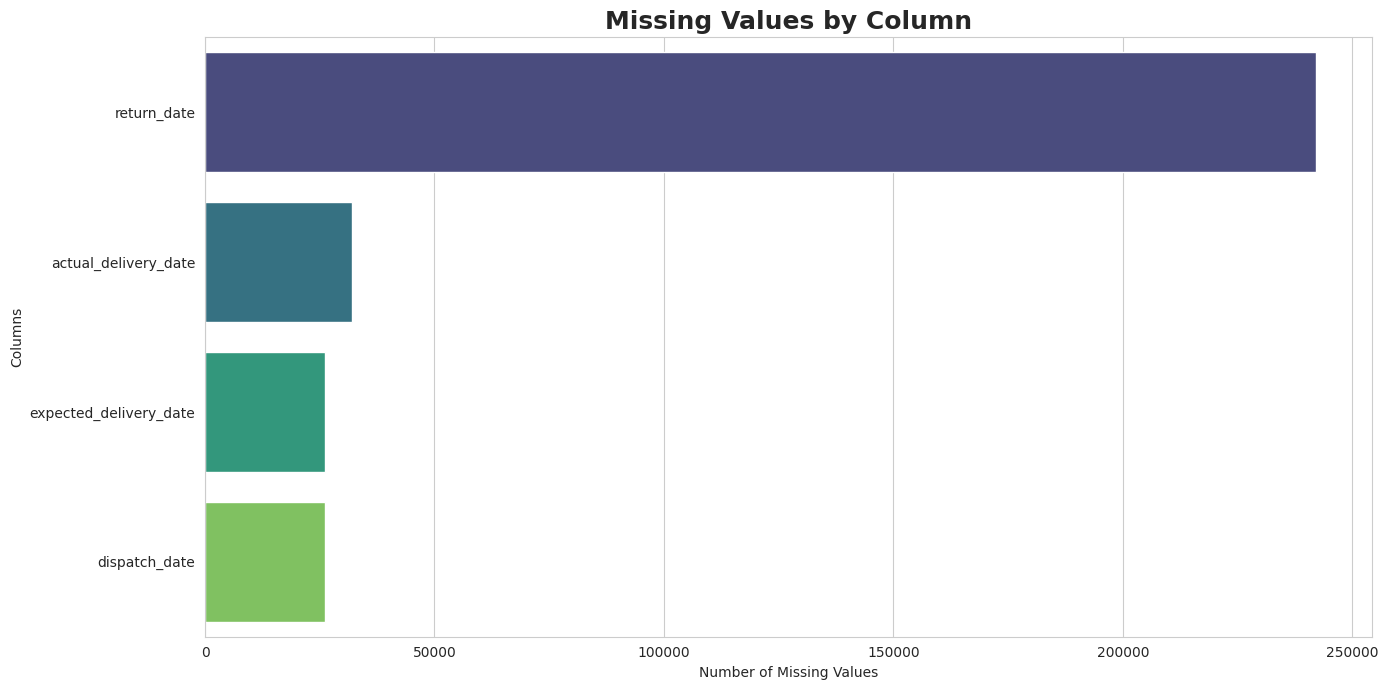


Number of duplicate rows: 0


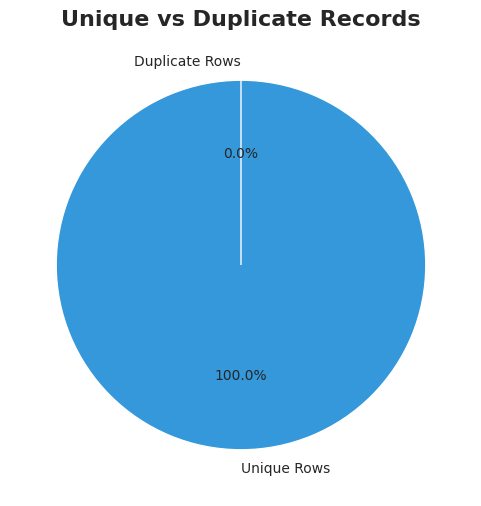


Numerical Columns:
['quantity', 'unit_price', 'discount_percentage_x', 'item_revenue', 'item_cost', 'profit', 'discount_percentage_y', 'subtotal', 'shipping_fee', 'tax_amount', 'final_amount', 'age', 'pincode_prefix', 'total_orders', 'total_spend', 'average_order_value', 'price', 'cost_price', 'rating_average', 'rating_count', 'stock_quantity', 'return_rate_baseline', 'amount_paid', 'transaction_fee', 'refund_amount', 'delivery_days', 'delayed_flag', 'refund_amount_ret', 'is_returned']


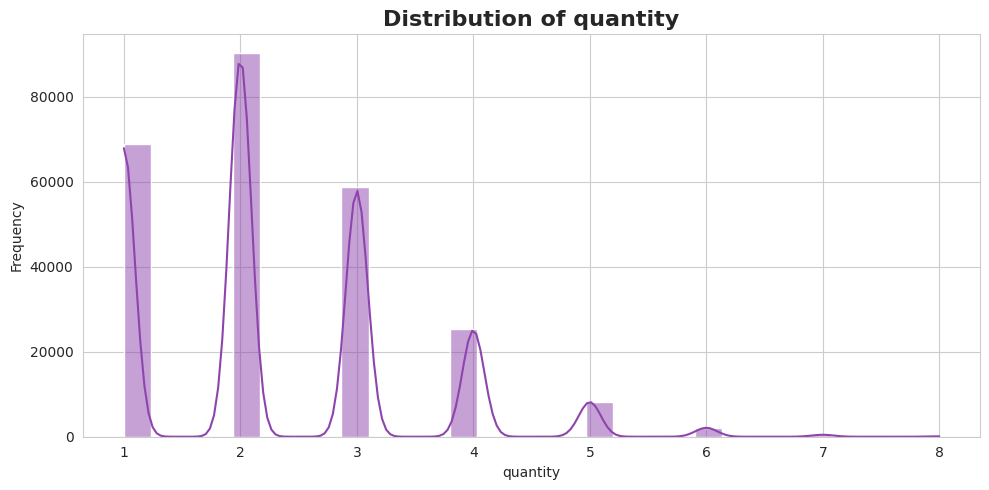

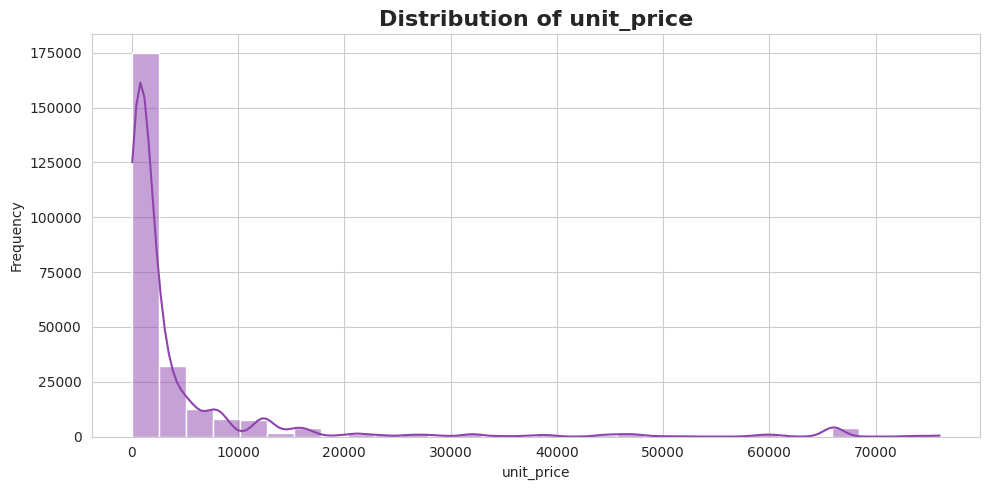

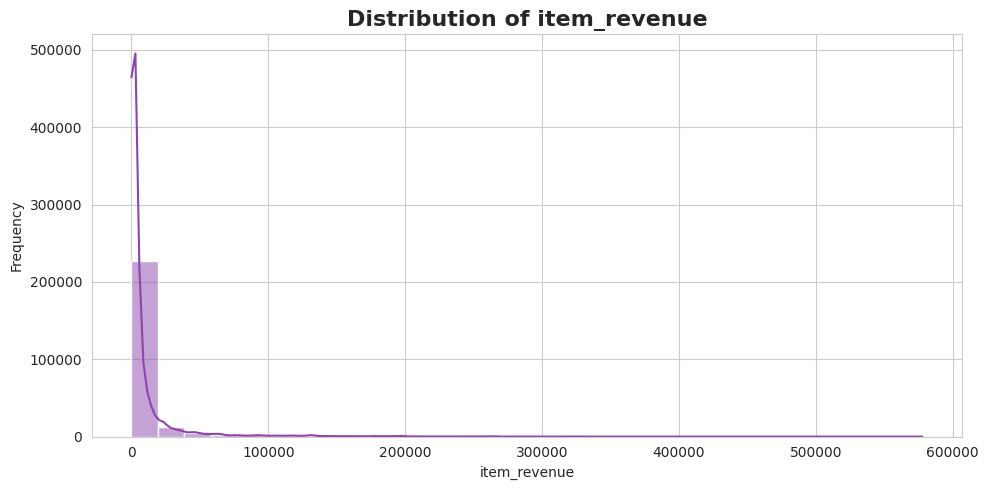

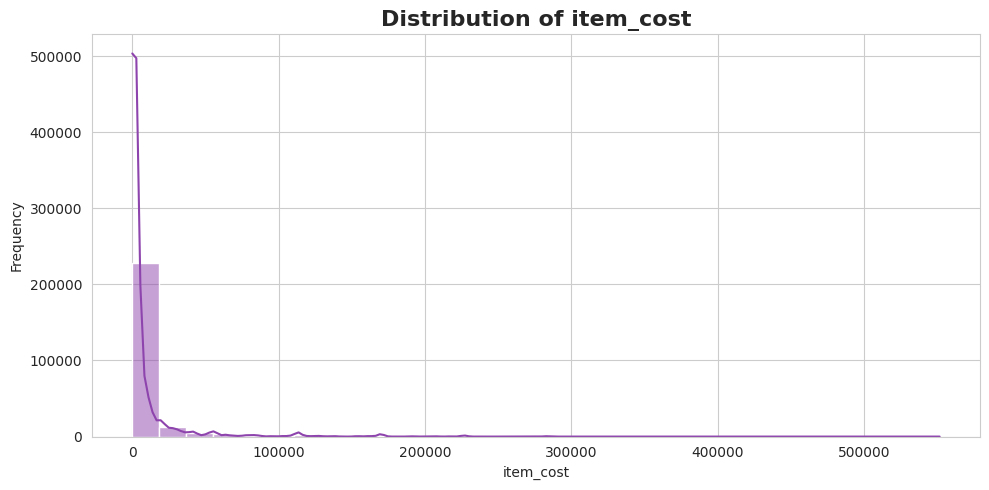

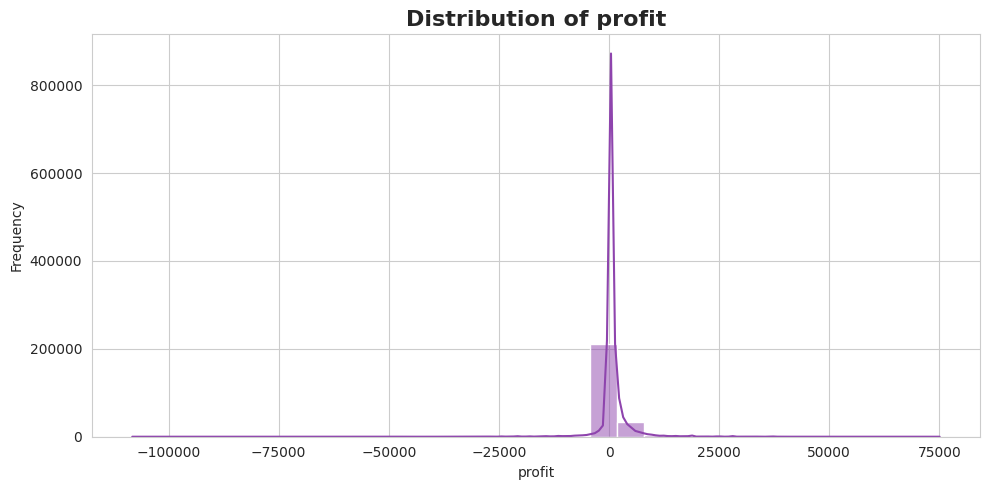

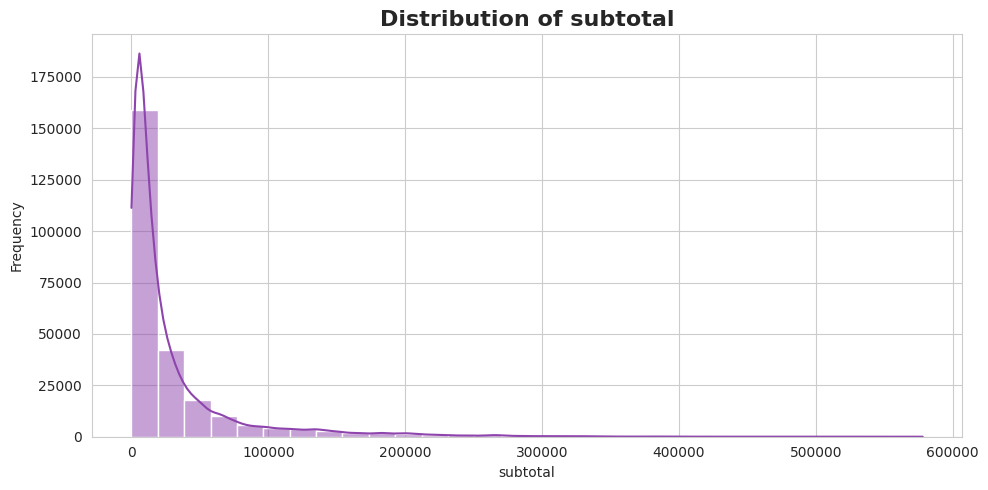

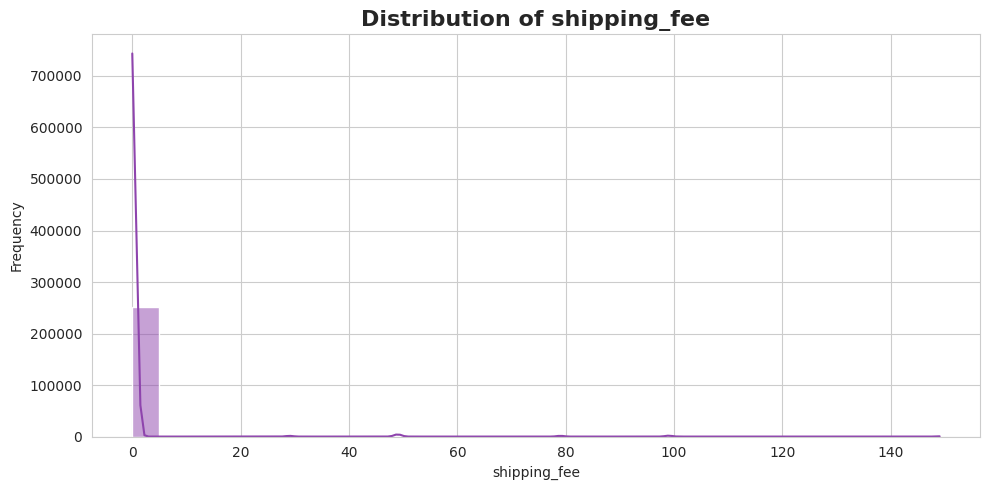

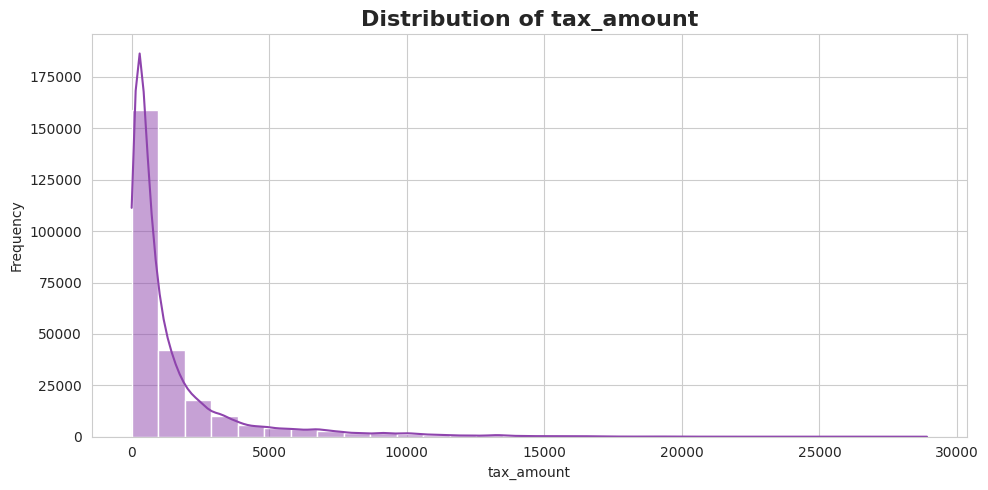

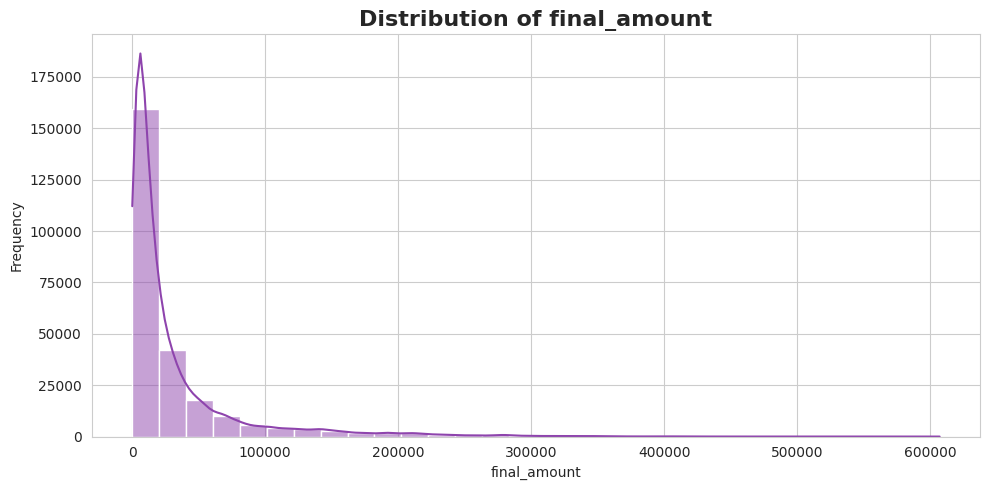

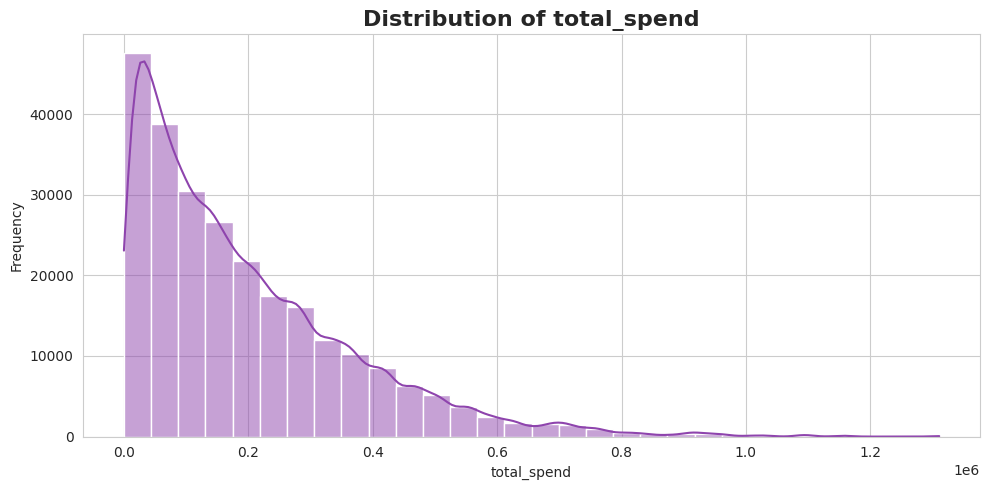

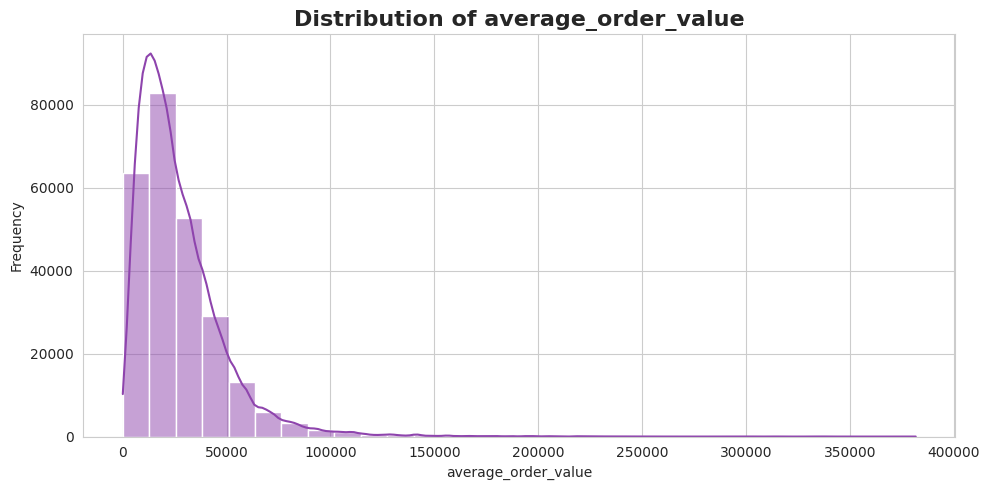

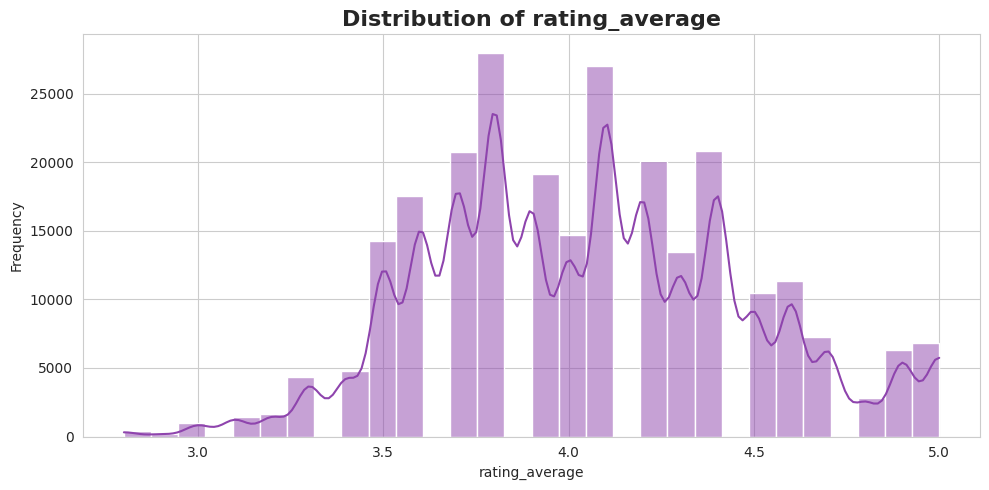

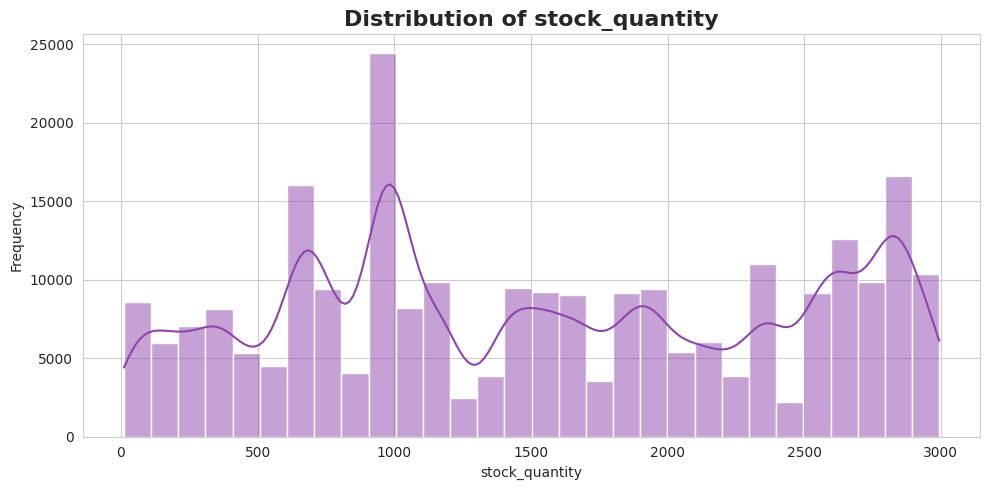

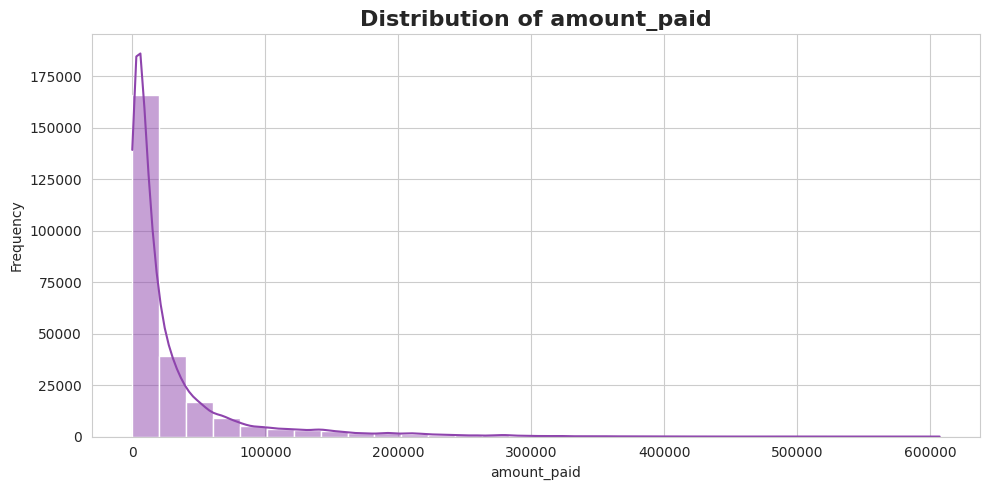

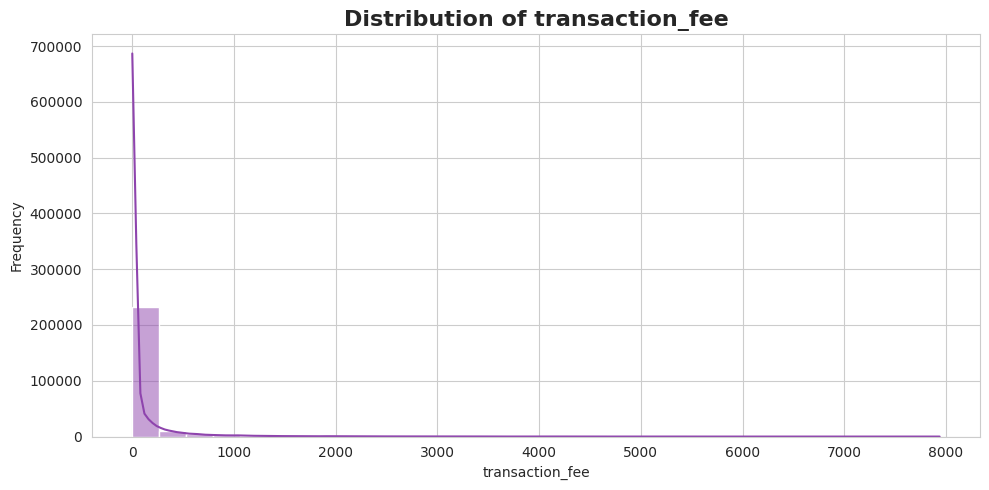

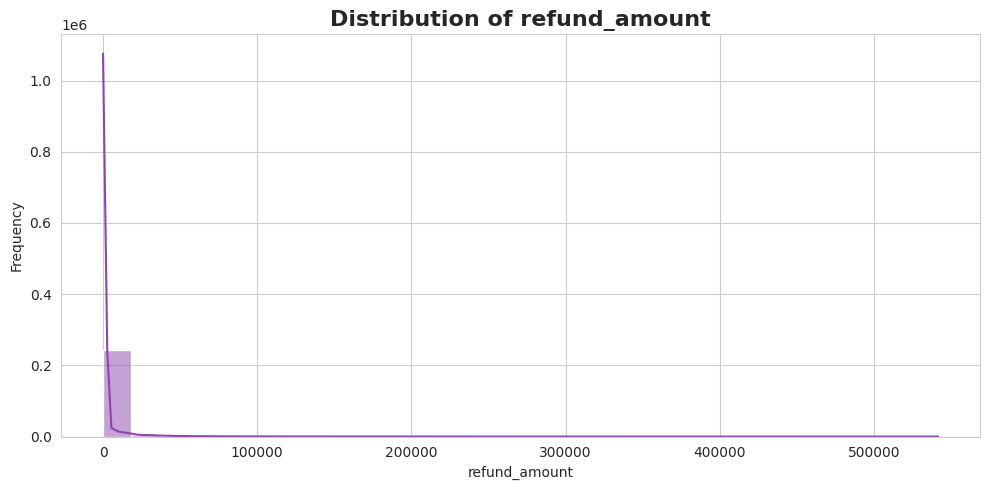

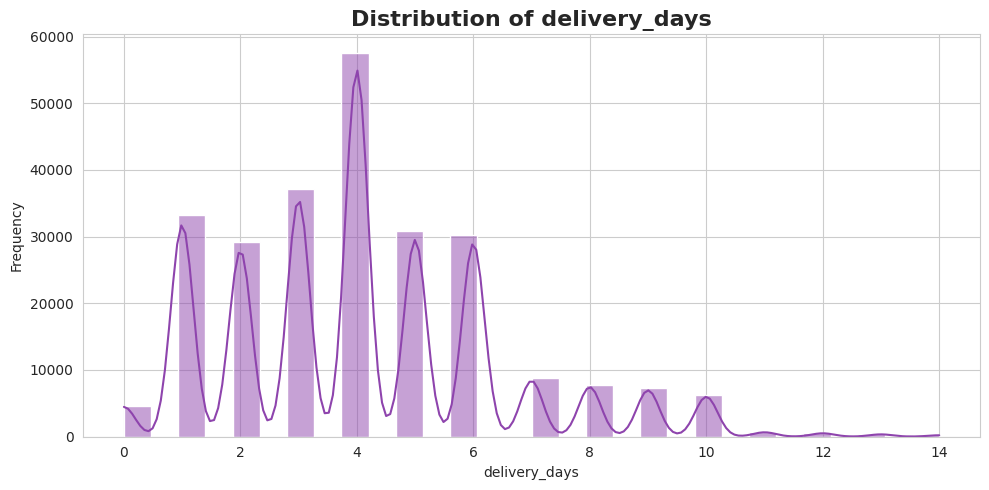

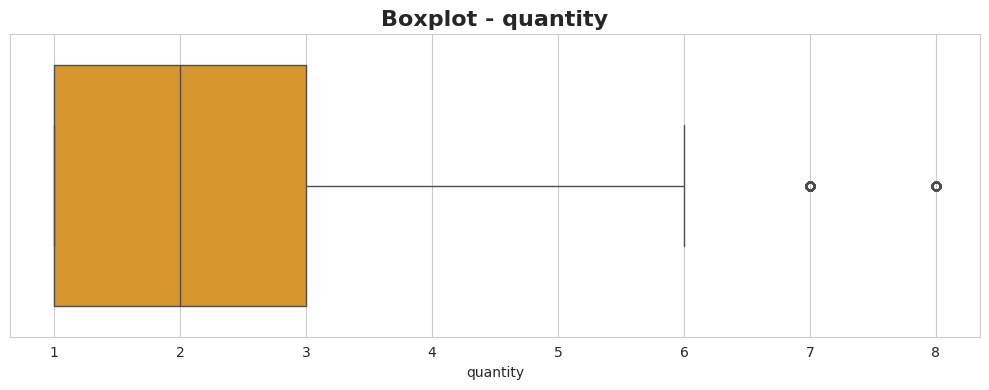

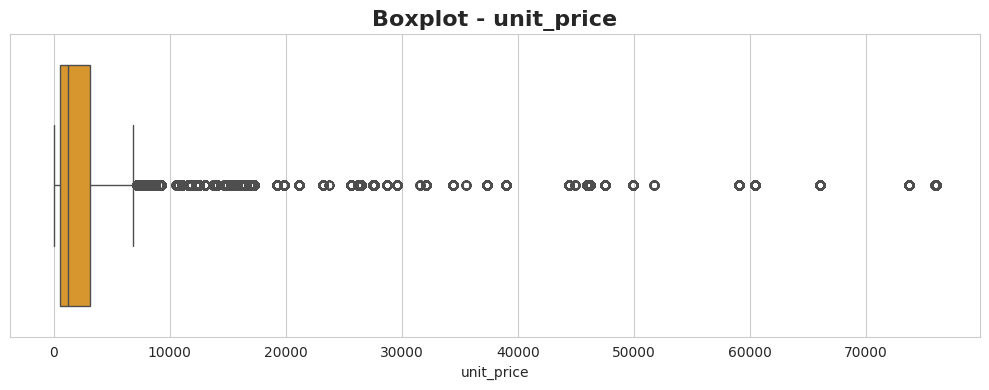

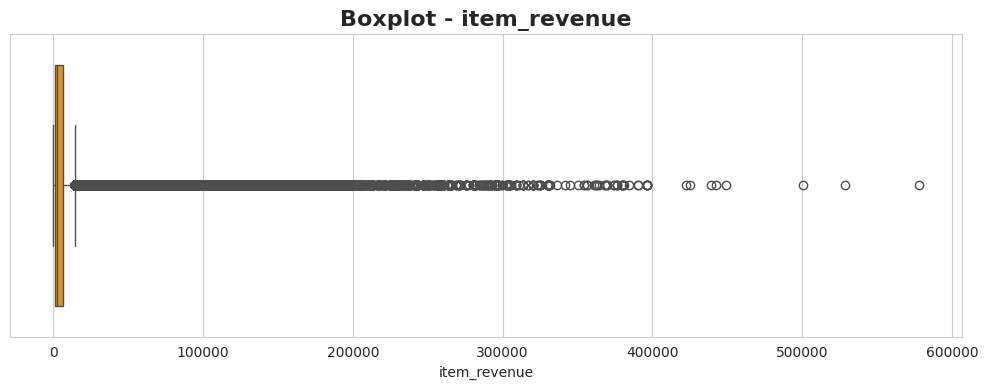

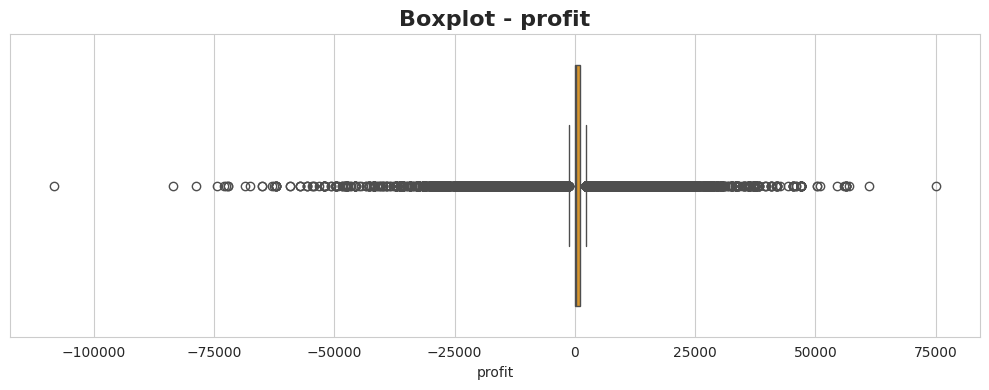

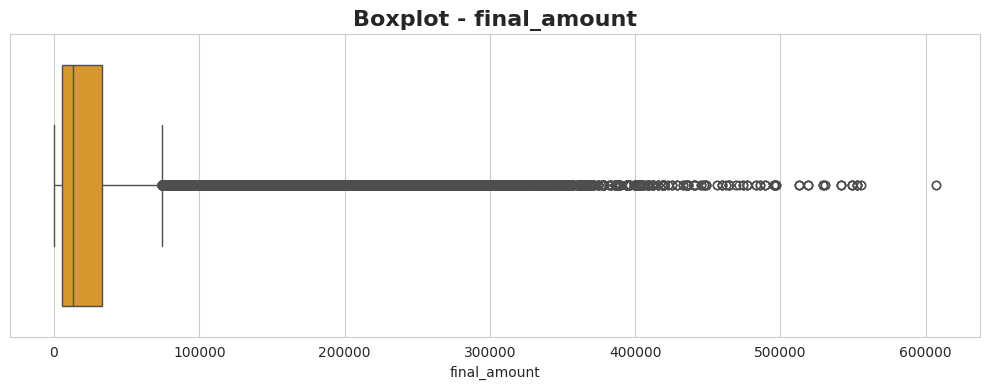

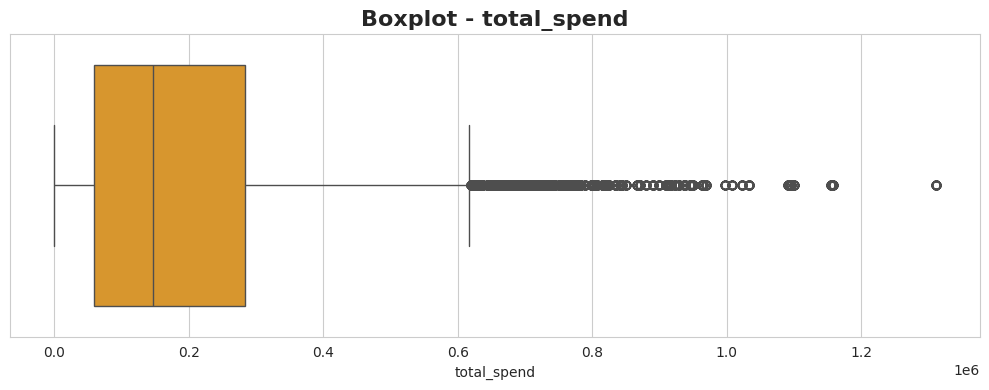

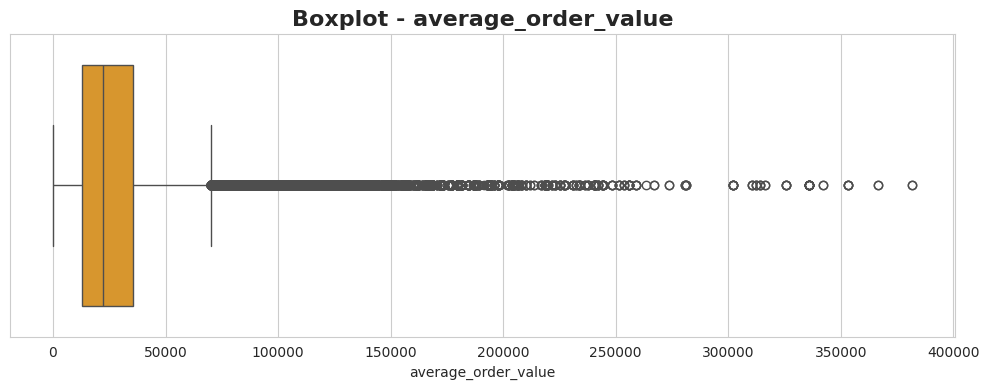

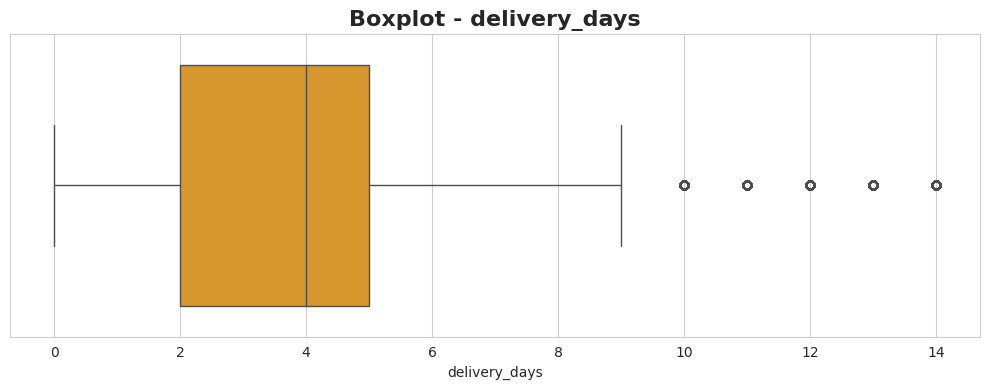


BUSINESS KPIs
Total Revenue       : 2,450,433,970.55
Total Profit        : 197,385,695.93
Total Quantity      : 585,823
Unique Orders       : 100,000
Unique Customers    : 22,820
Unique Products     : 550


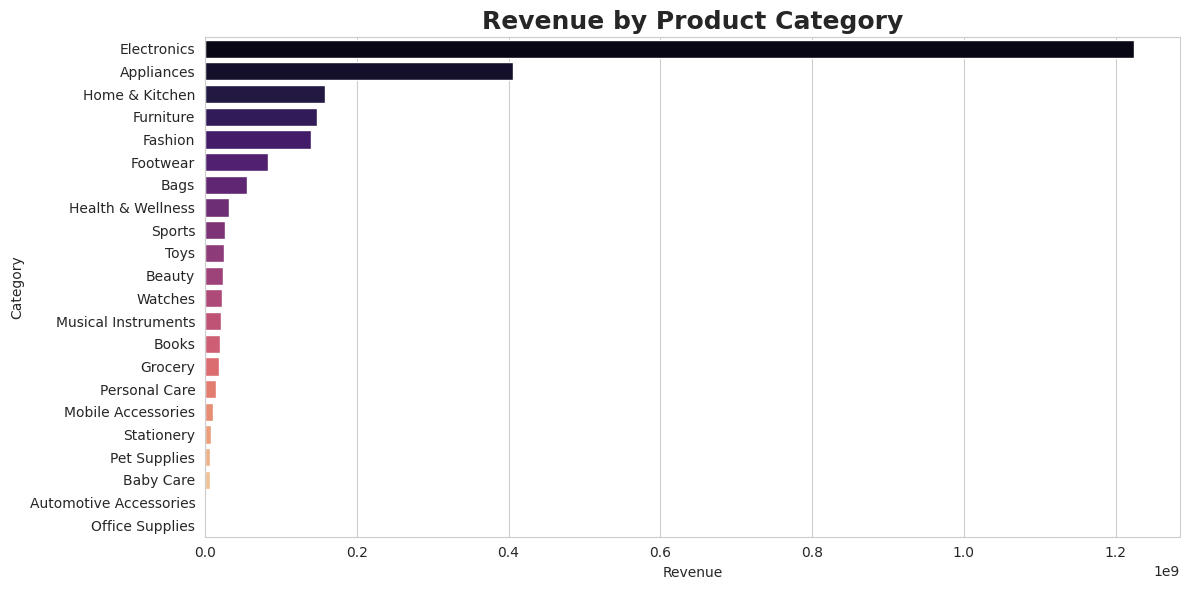

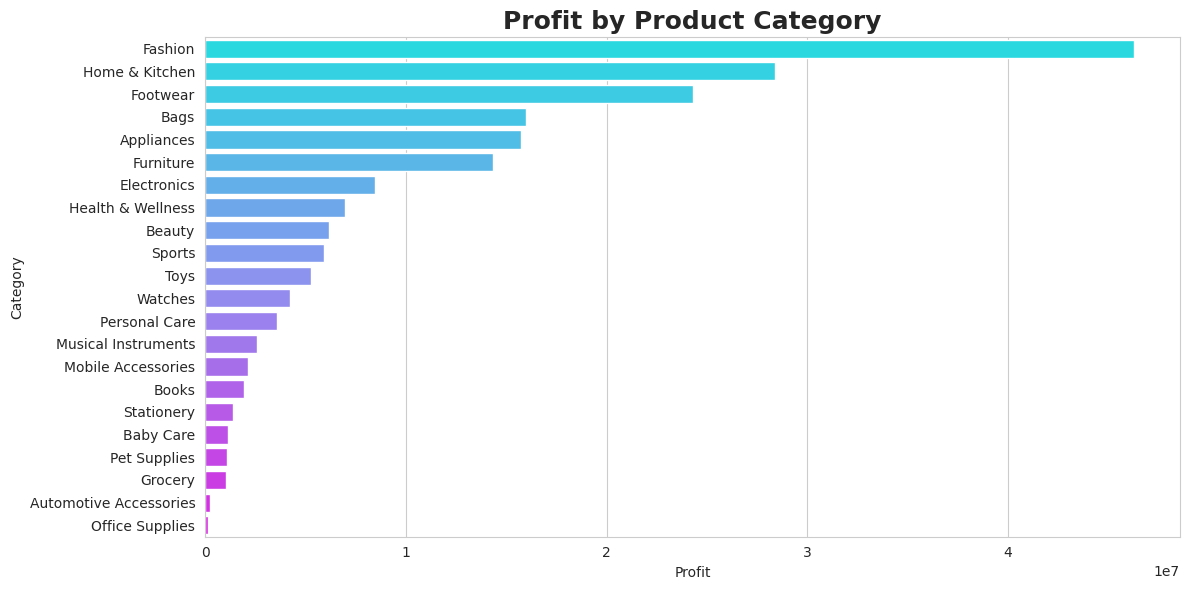

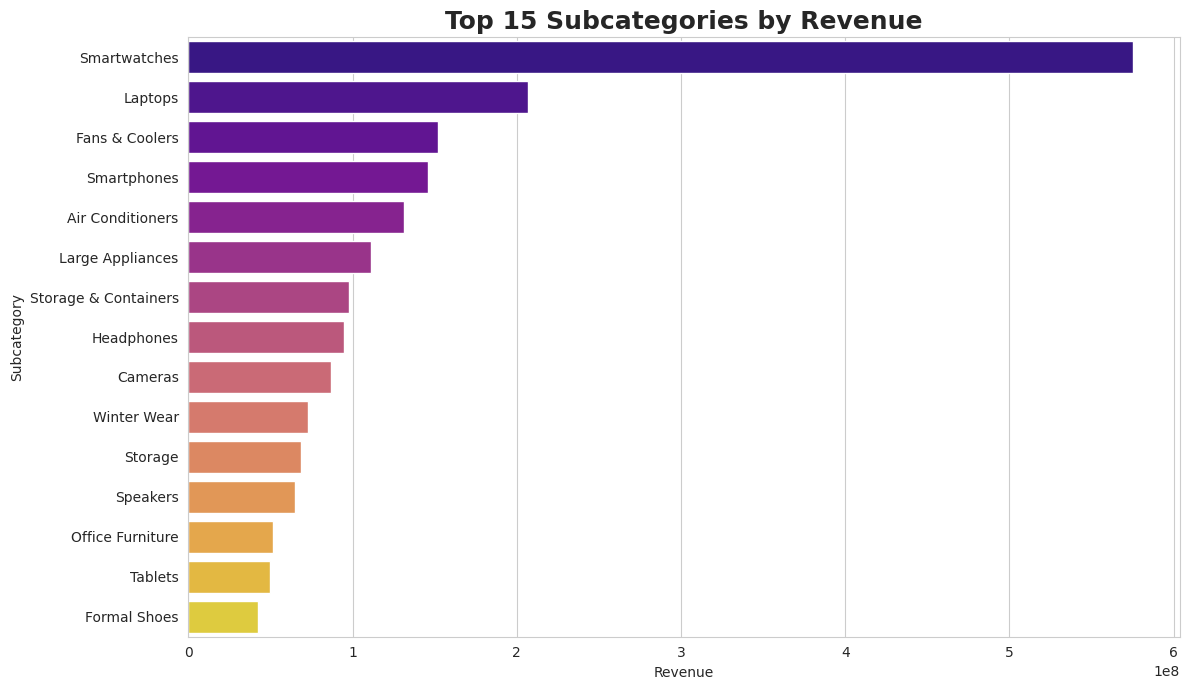

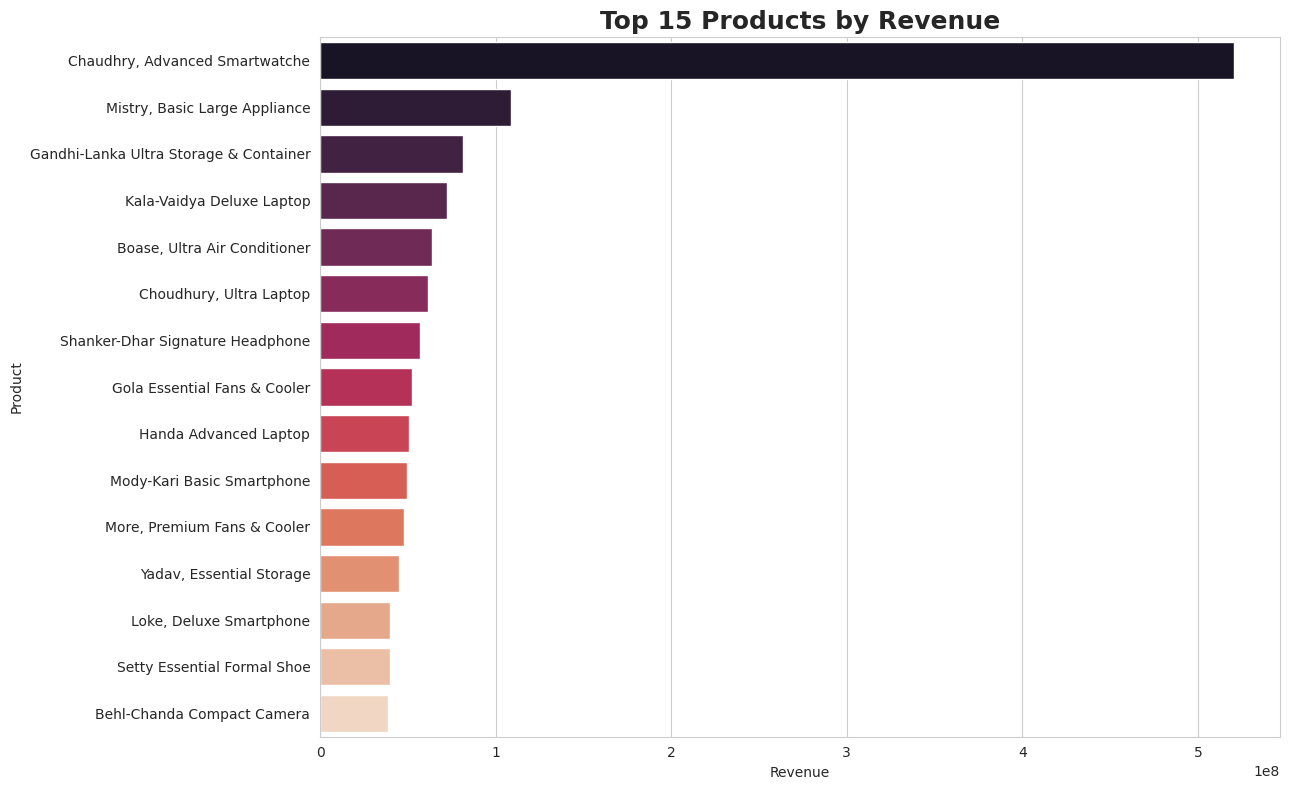

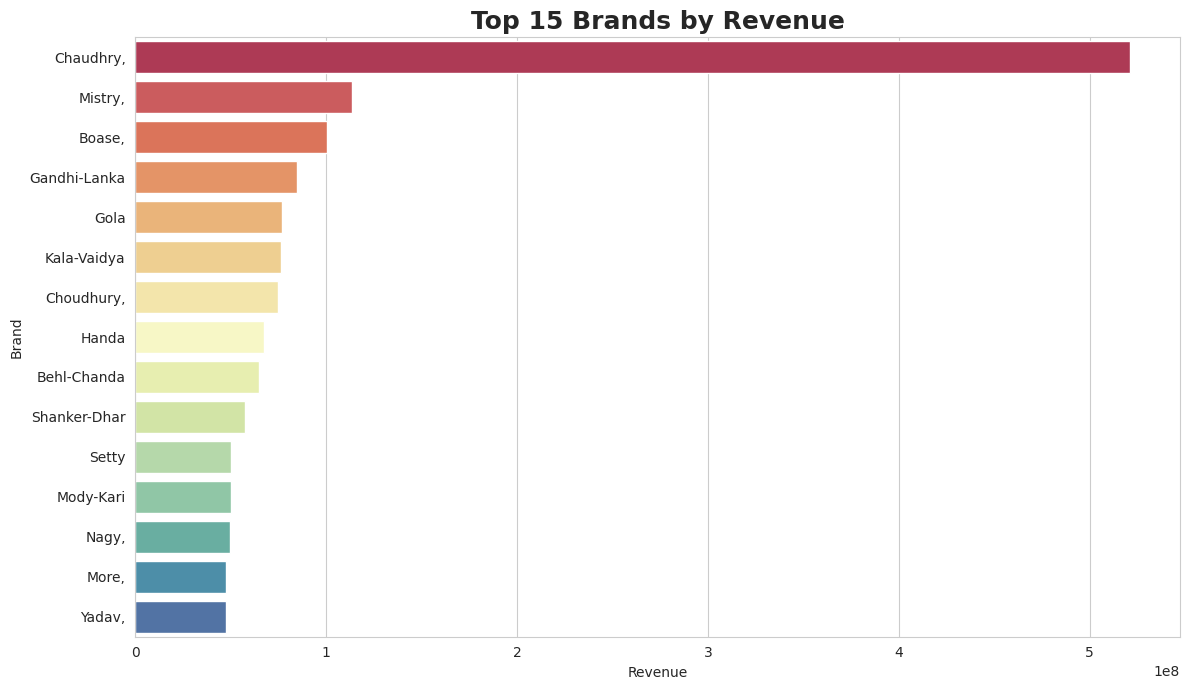

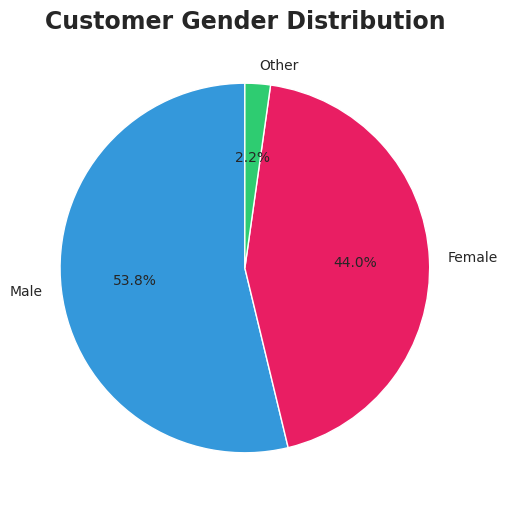

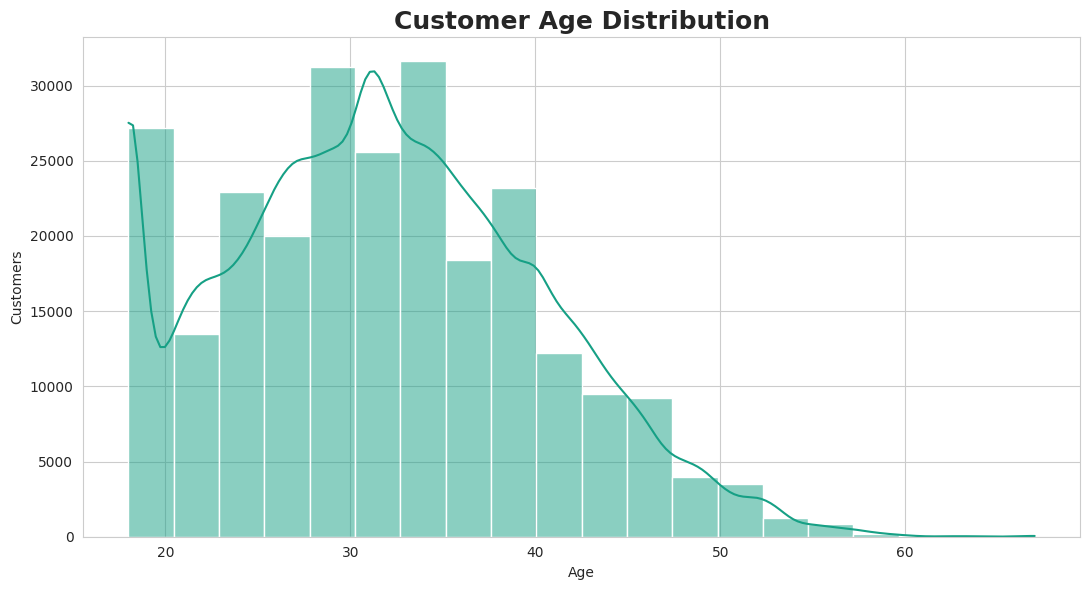

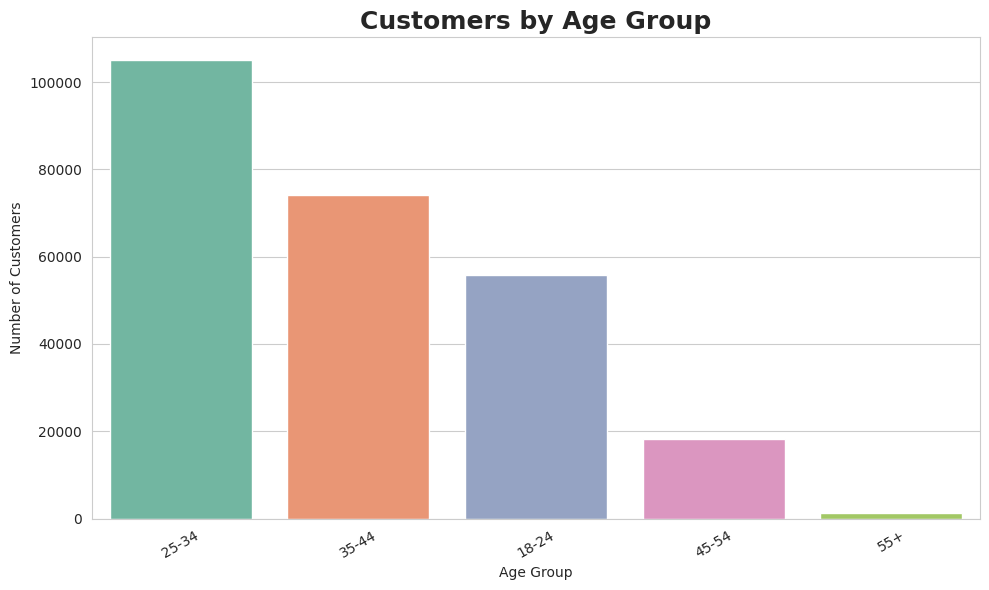

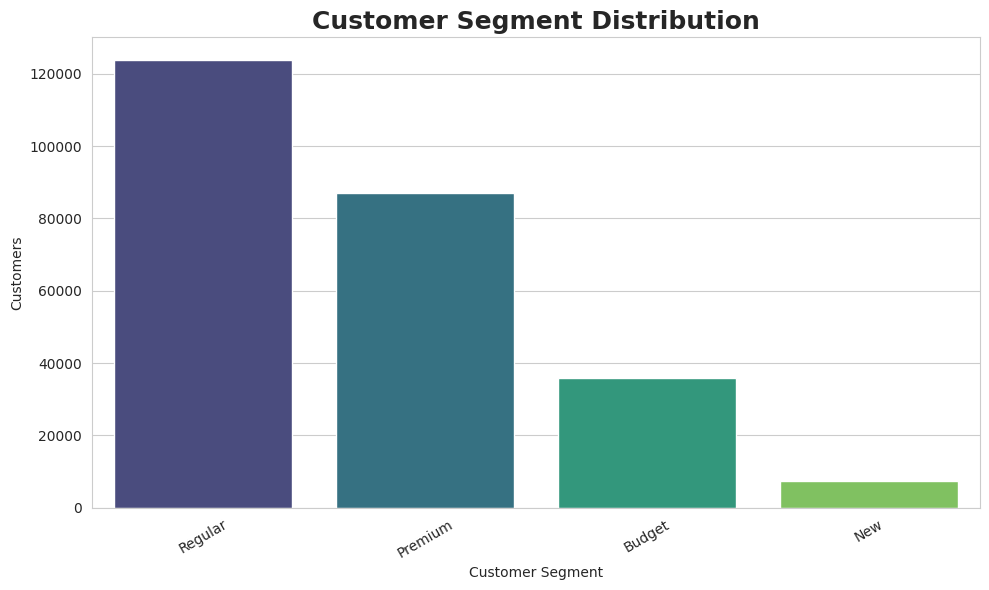

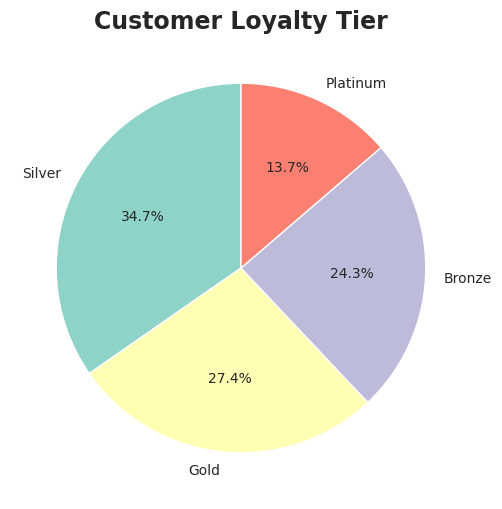

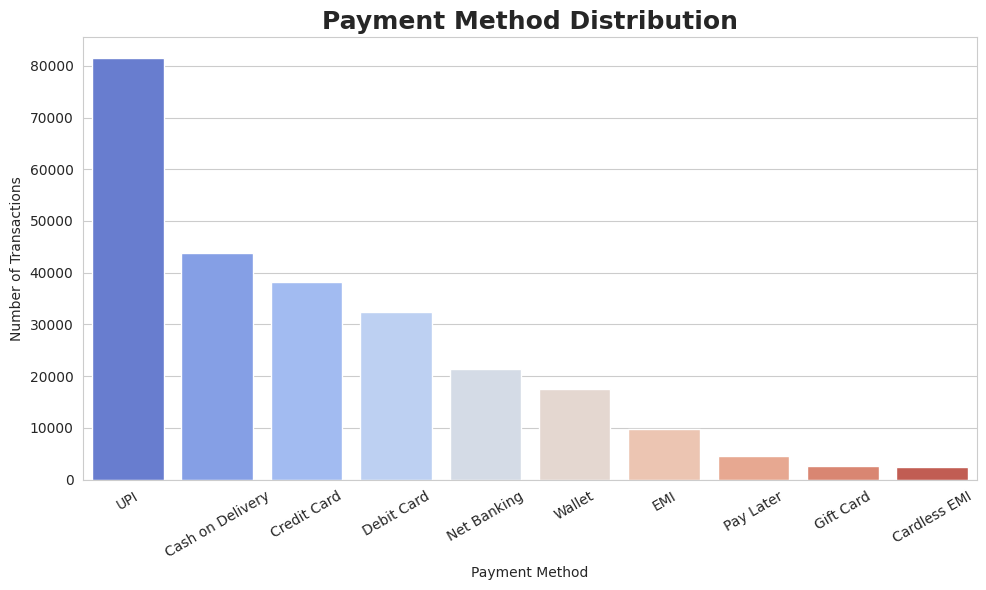

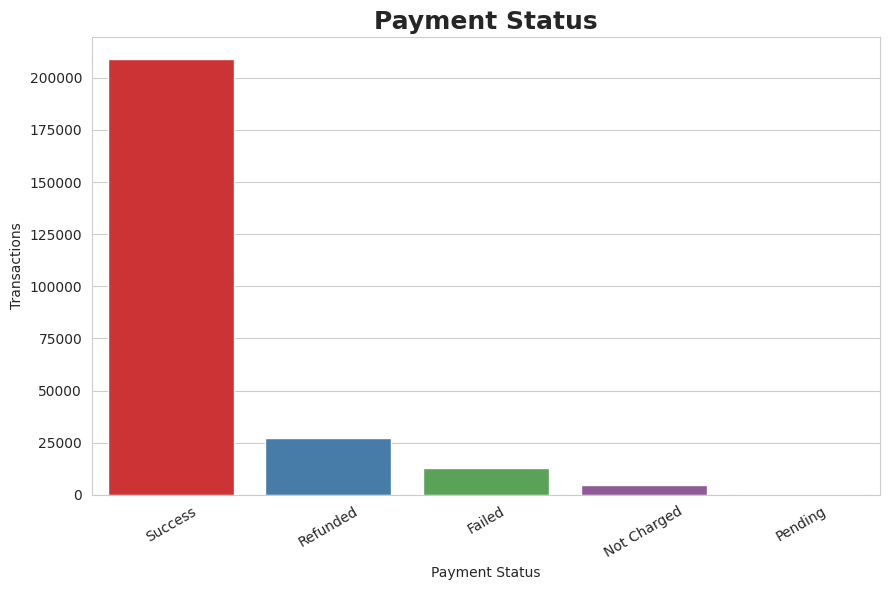

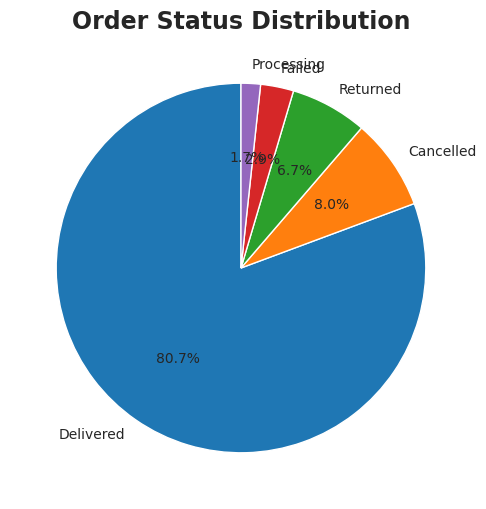

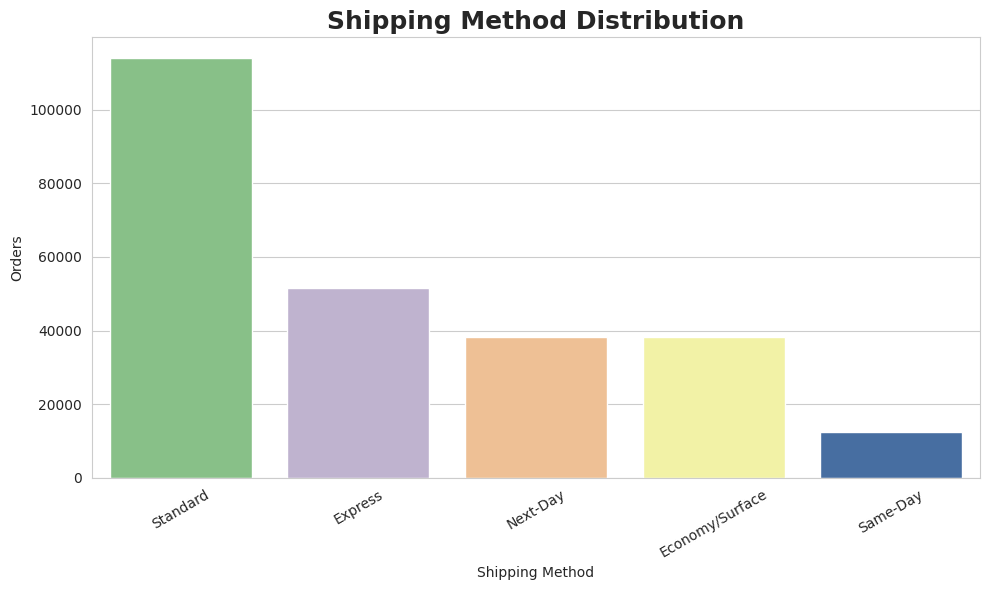

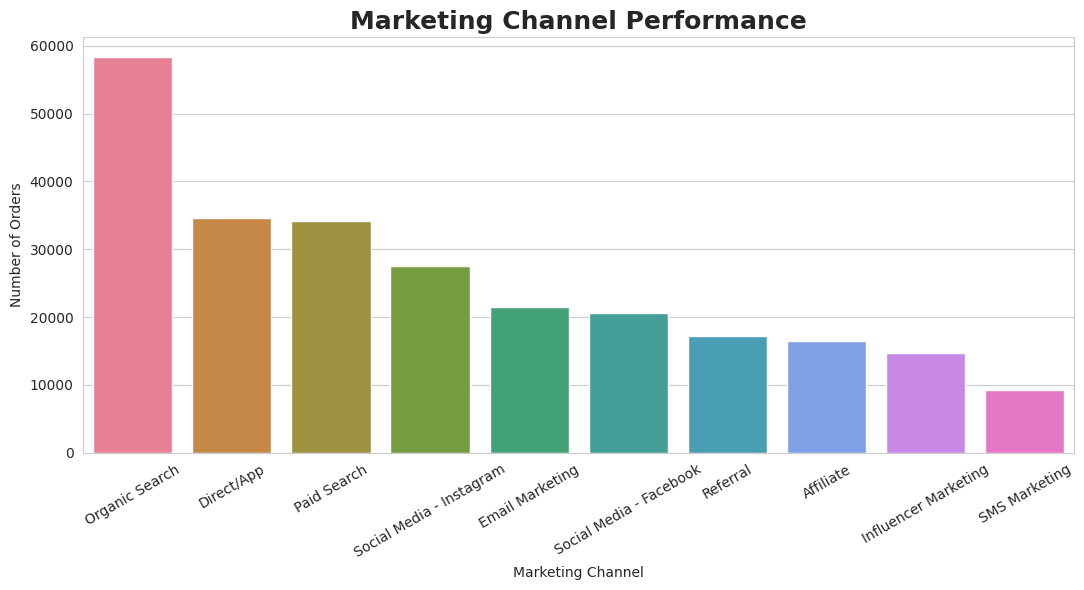

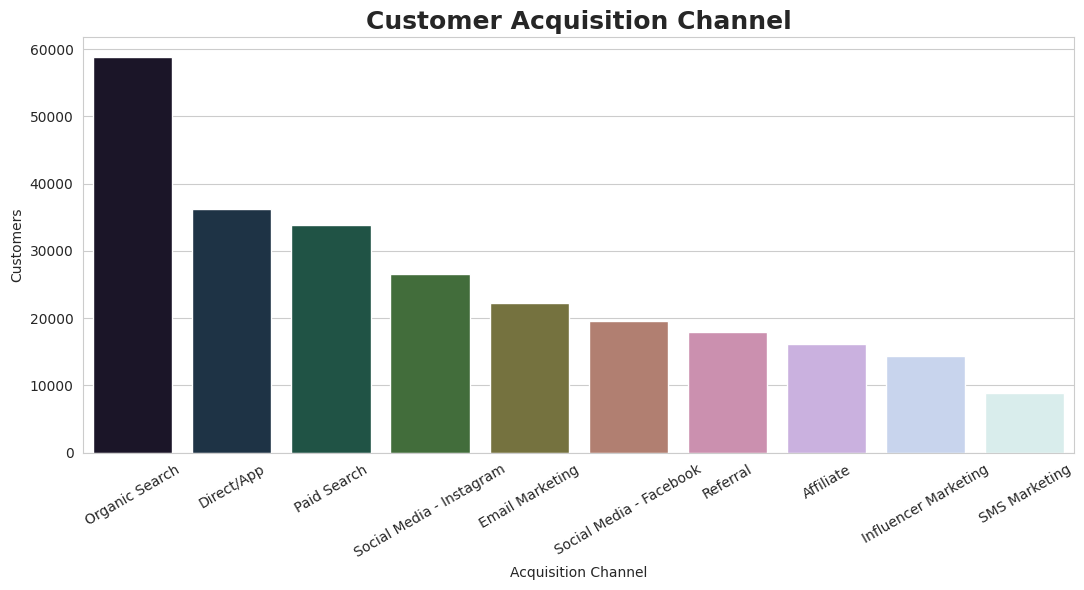

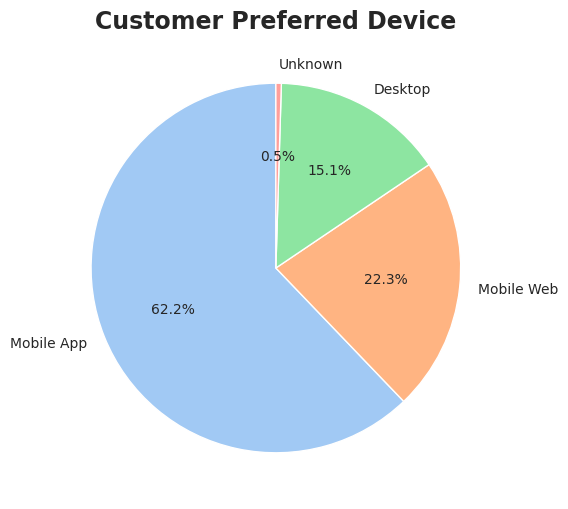

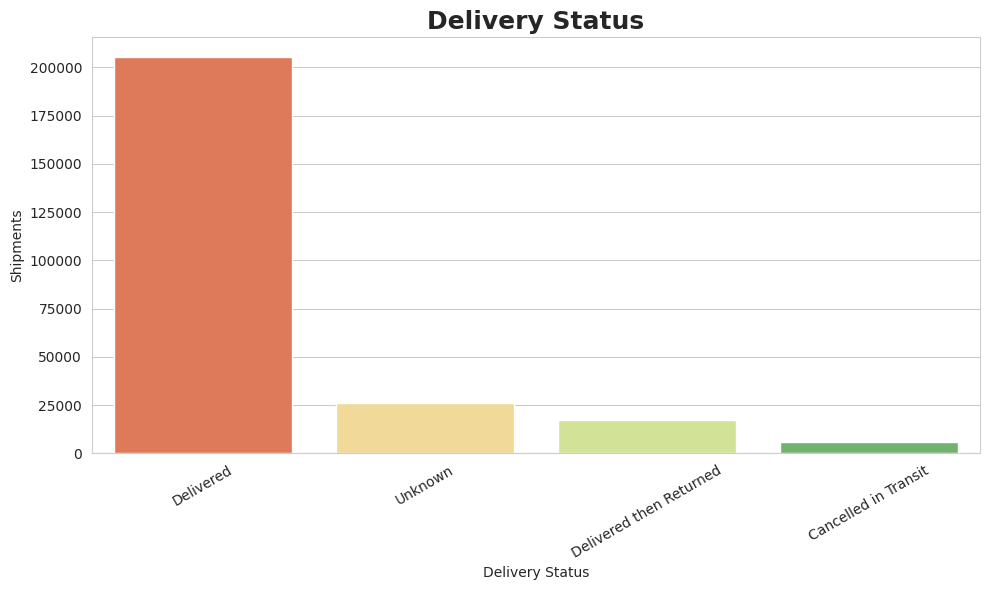

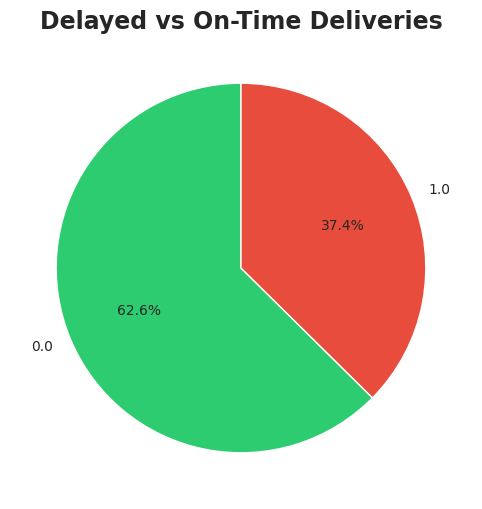

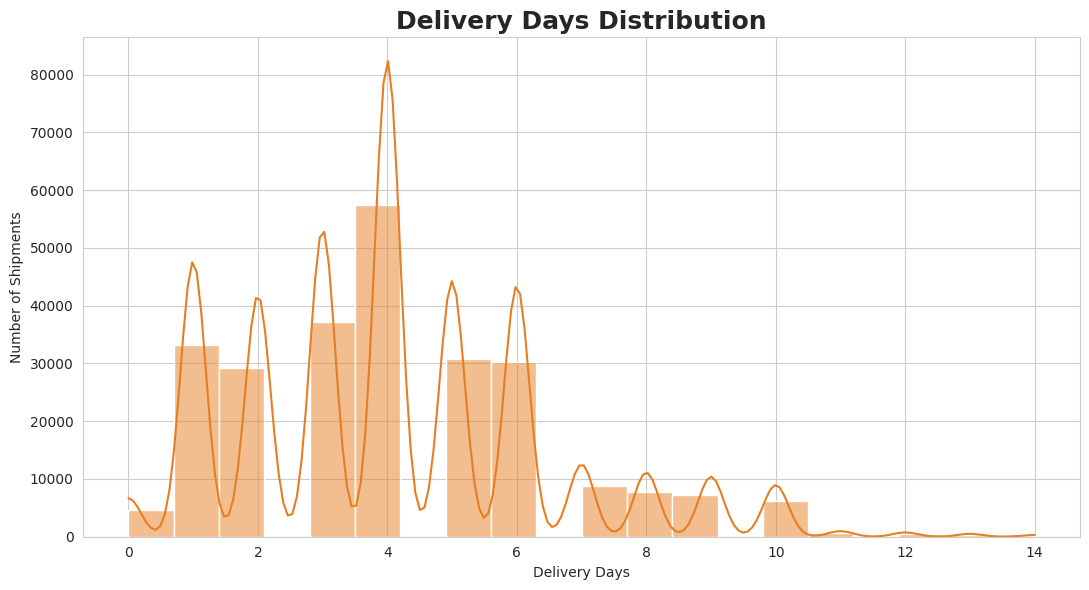

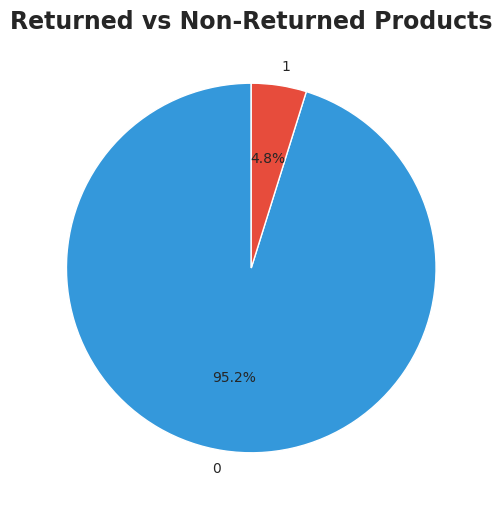

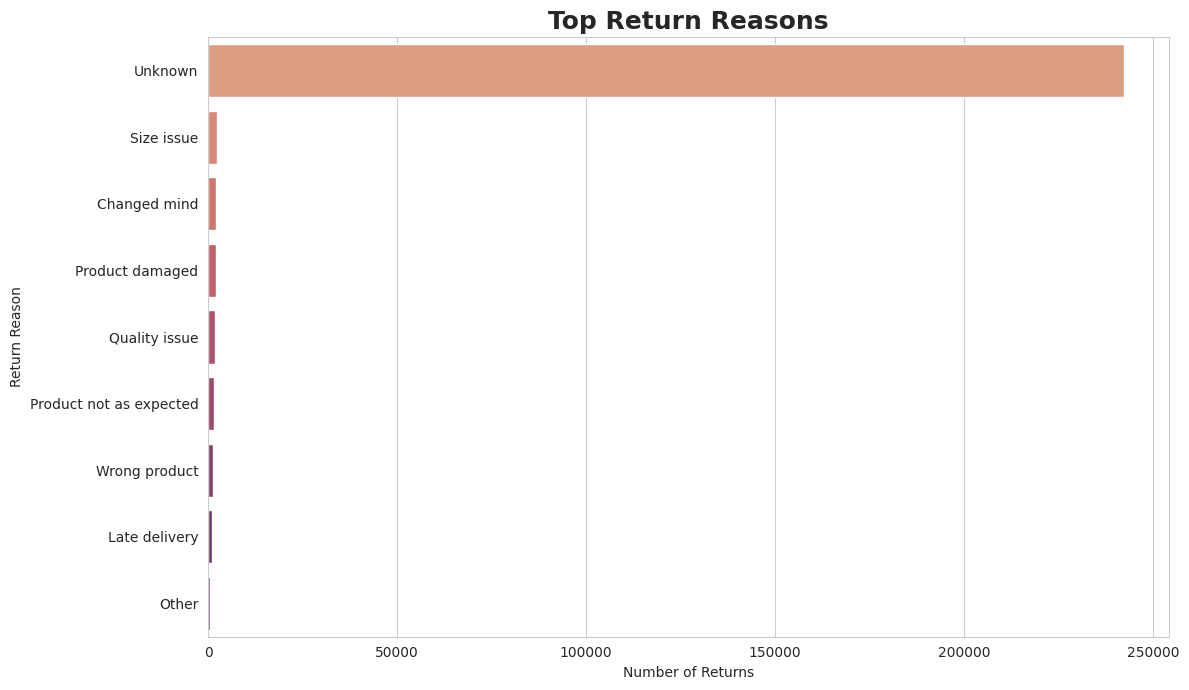

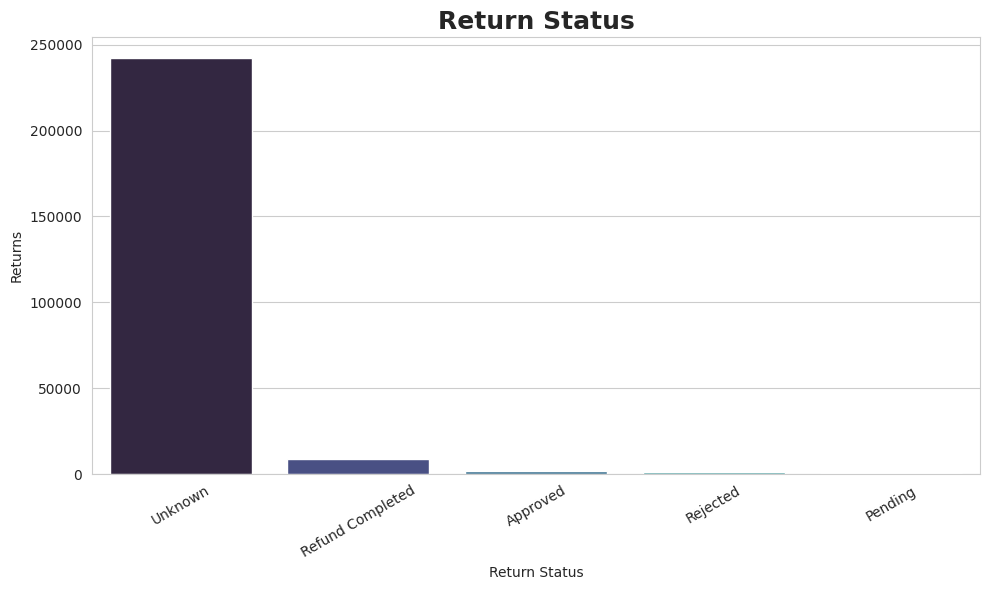

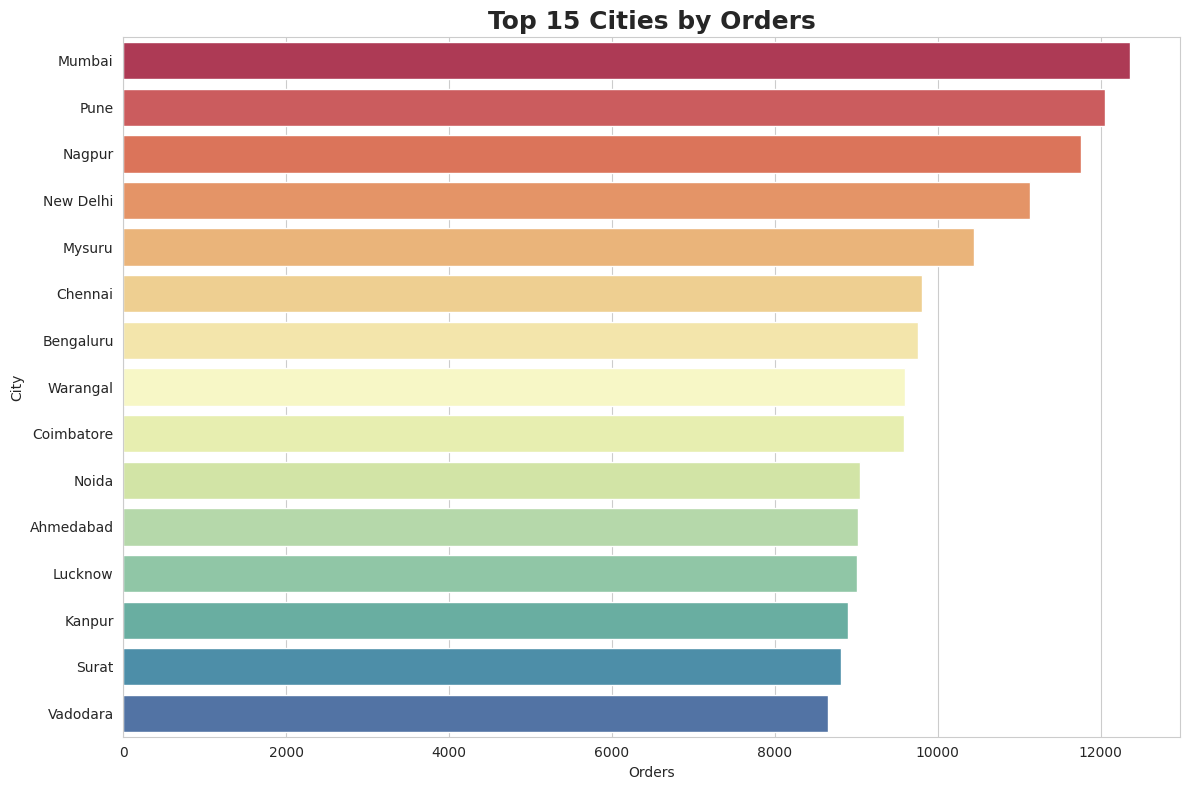

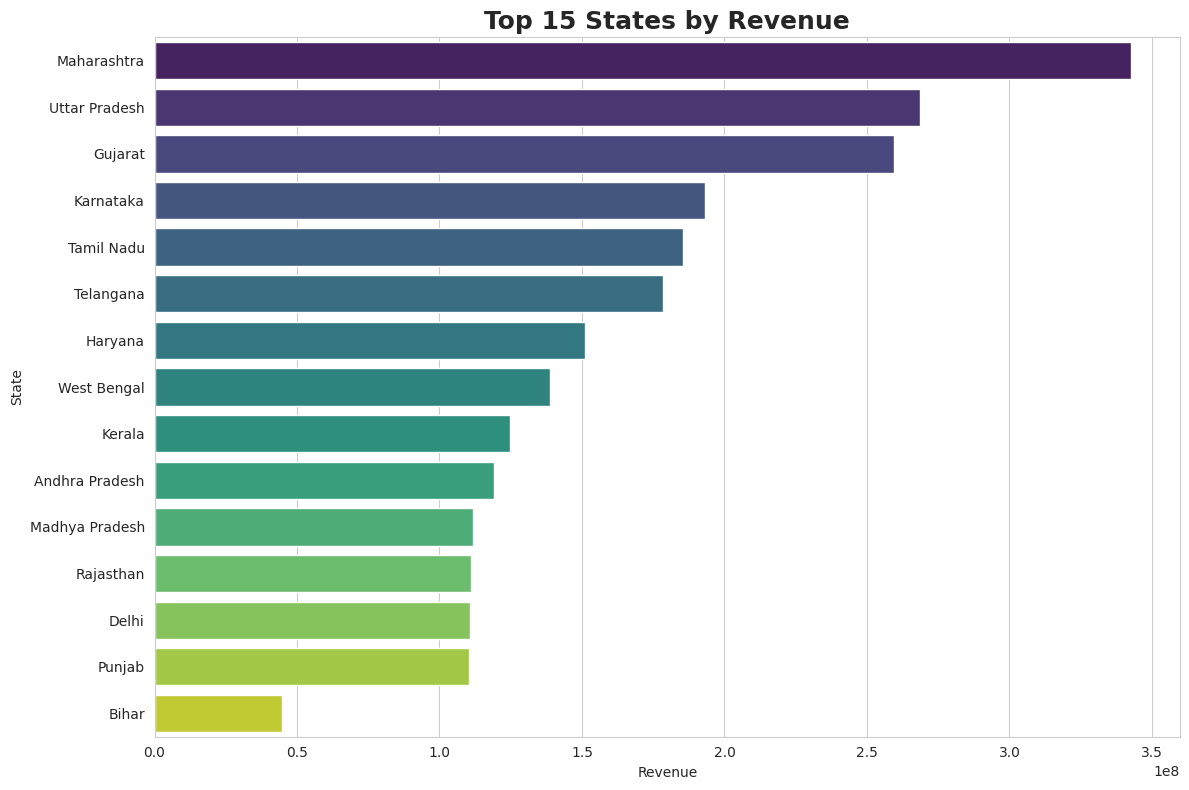

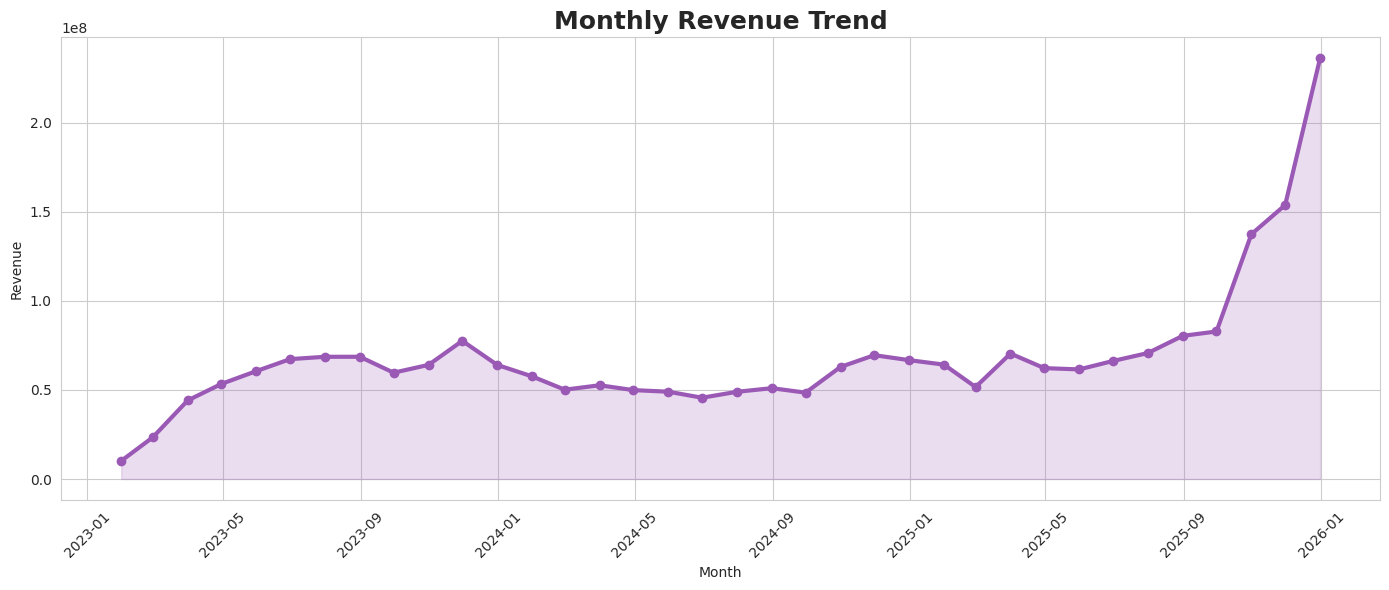

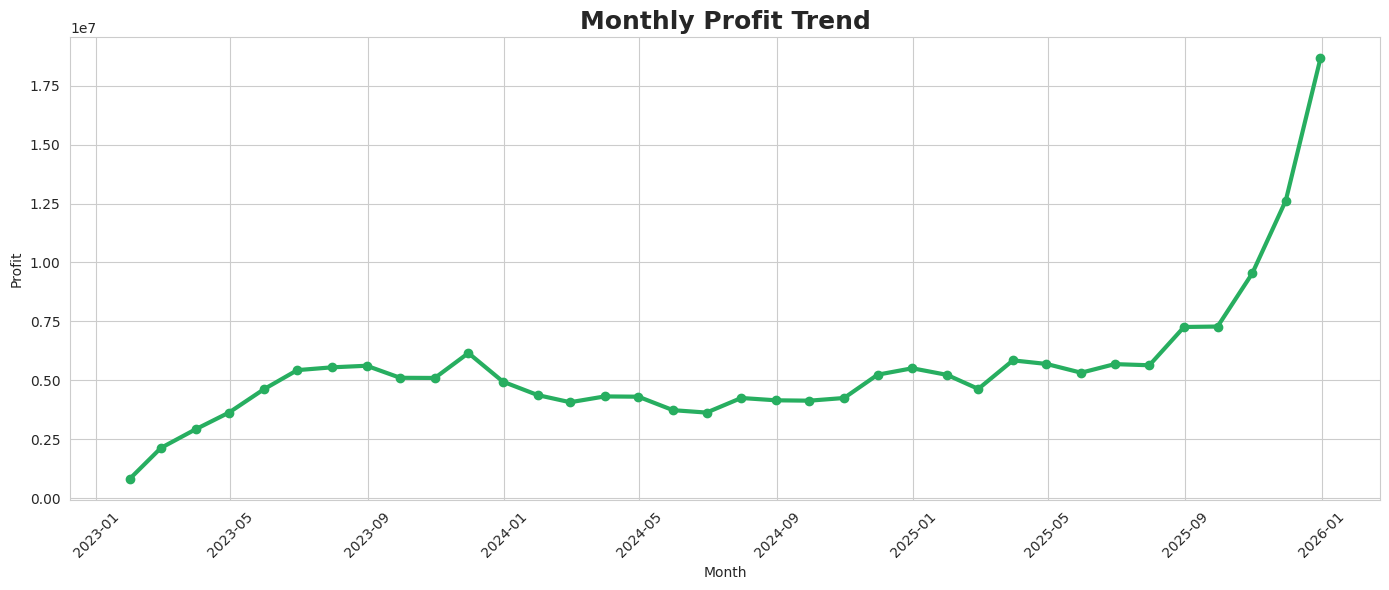

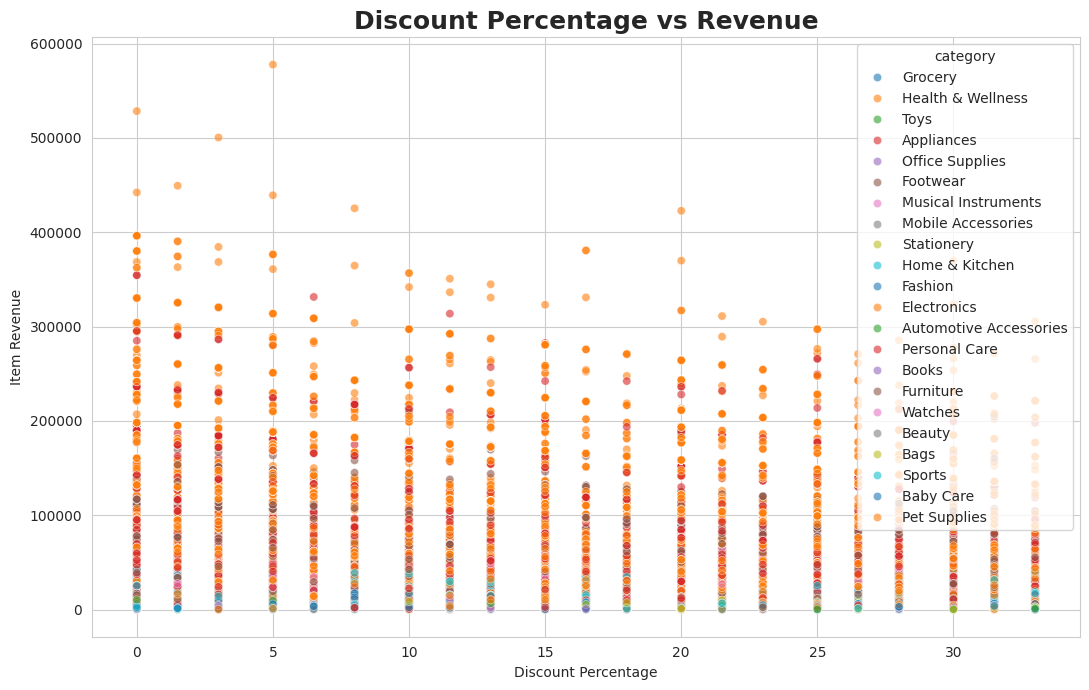

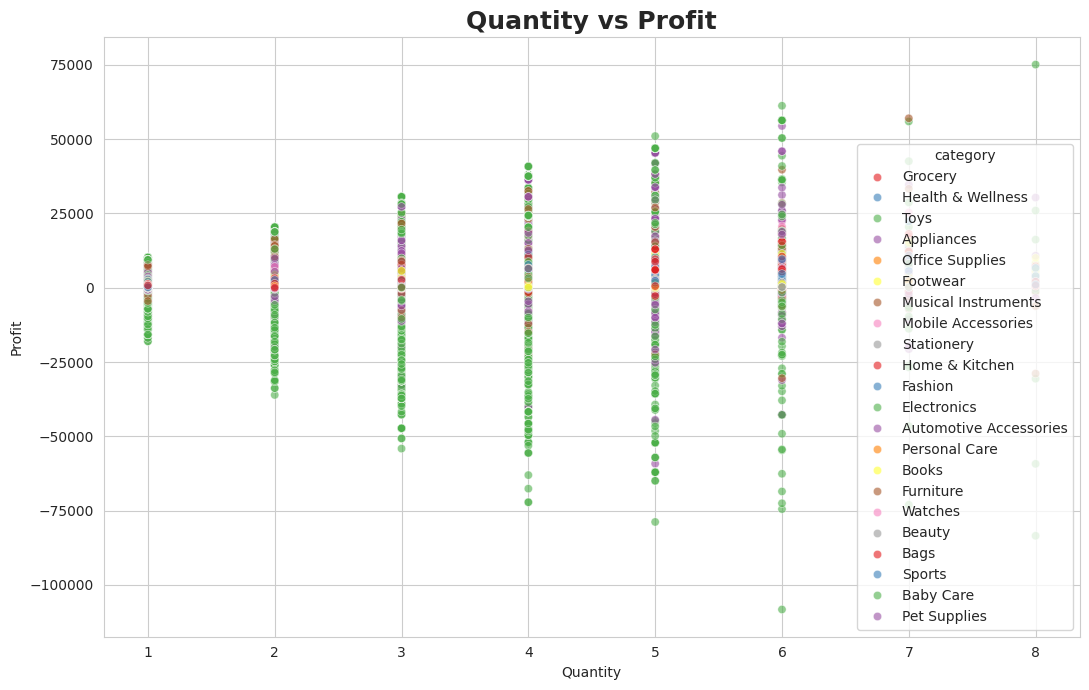

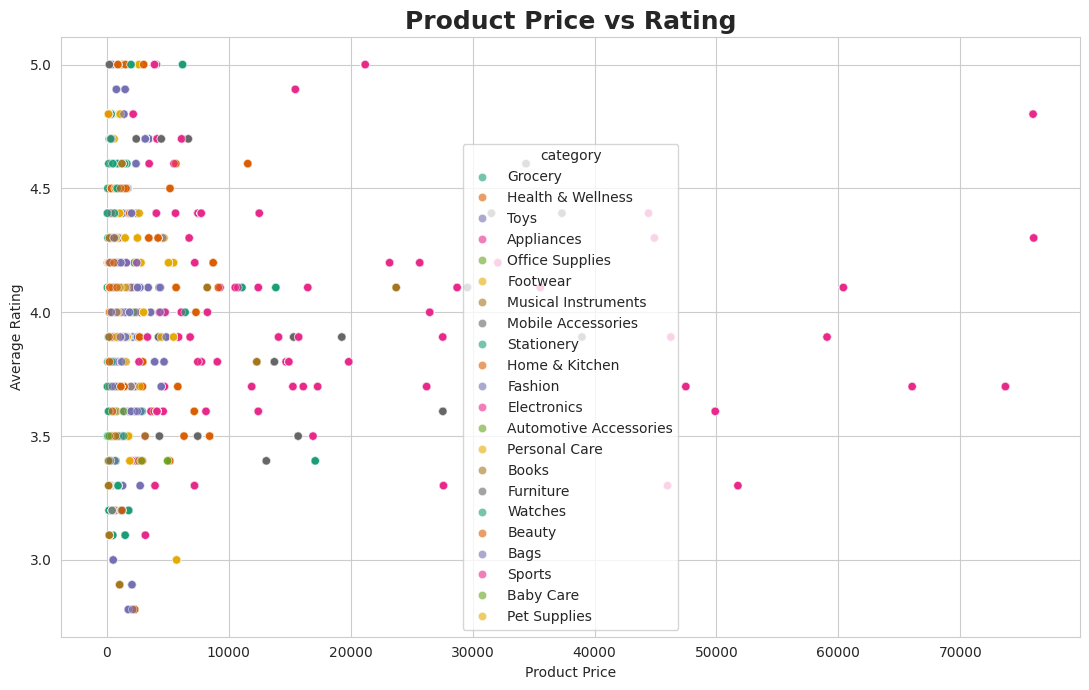

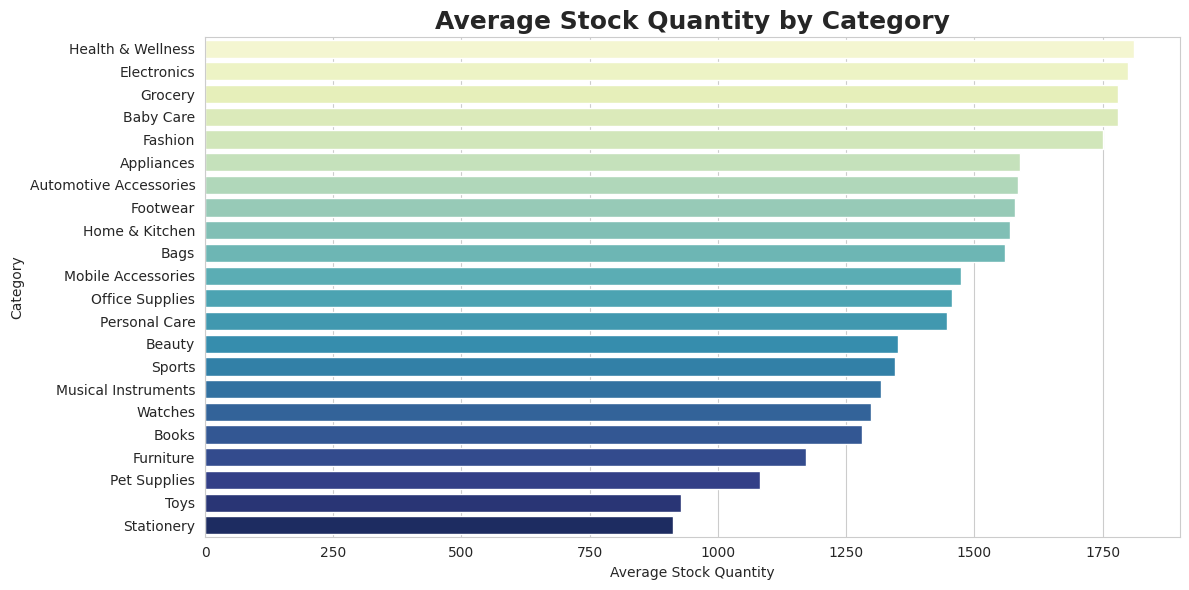

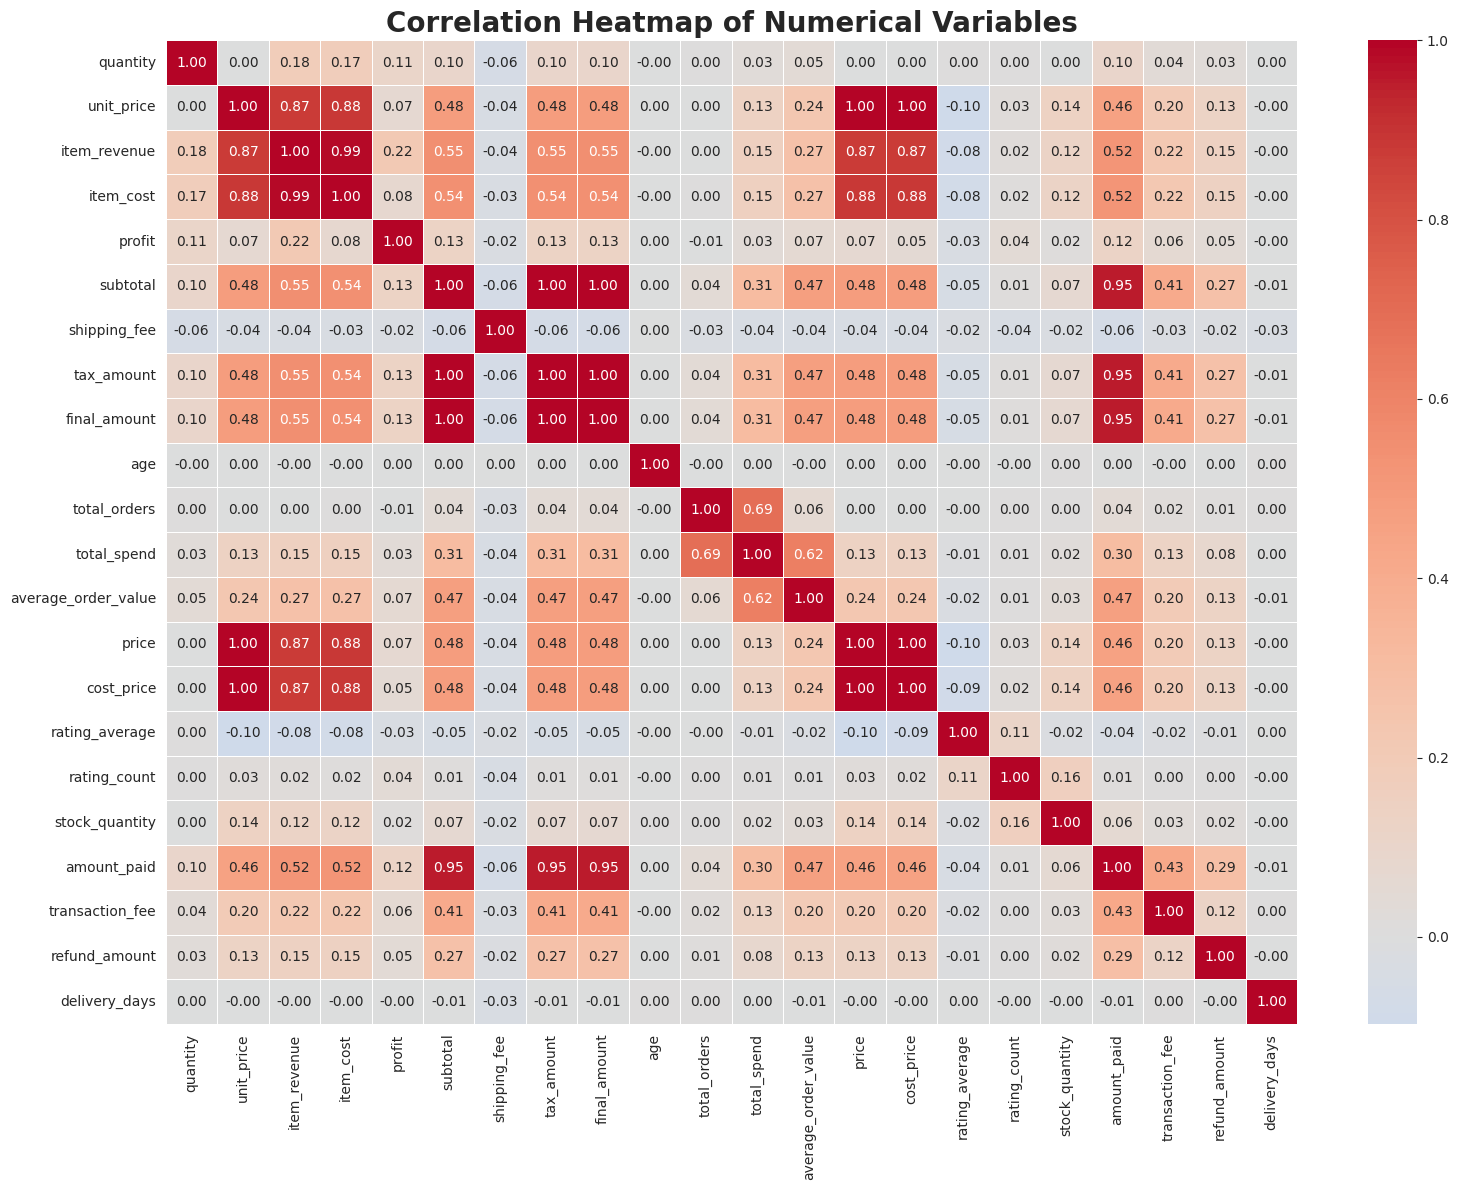

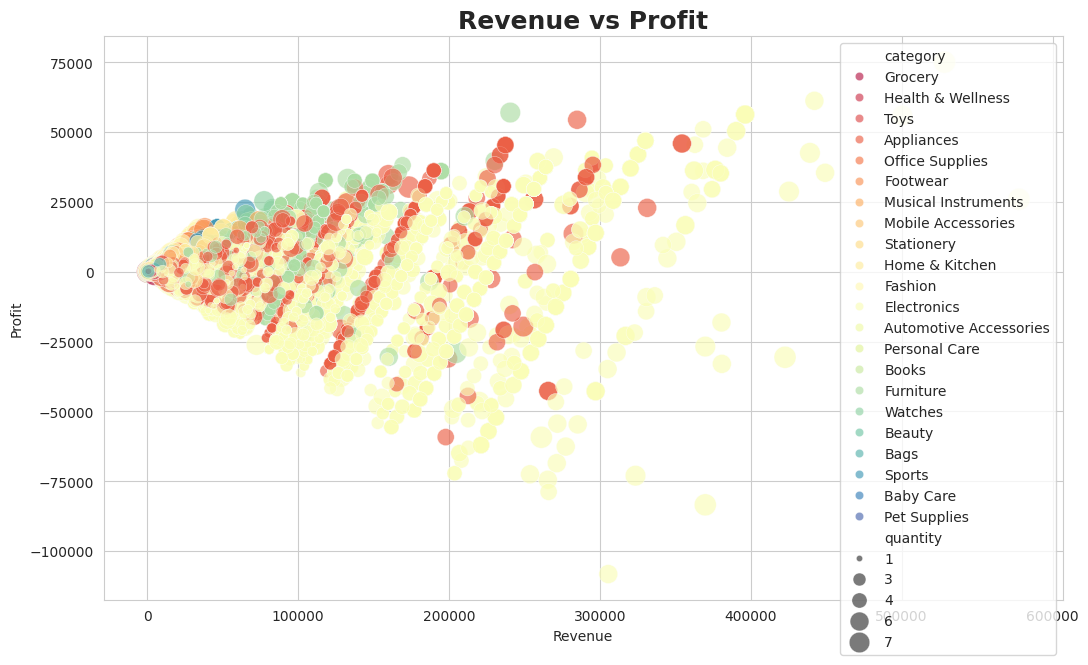

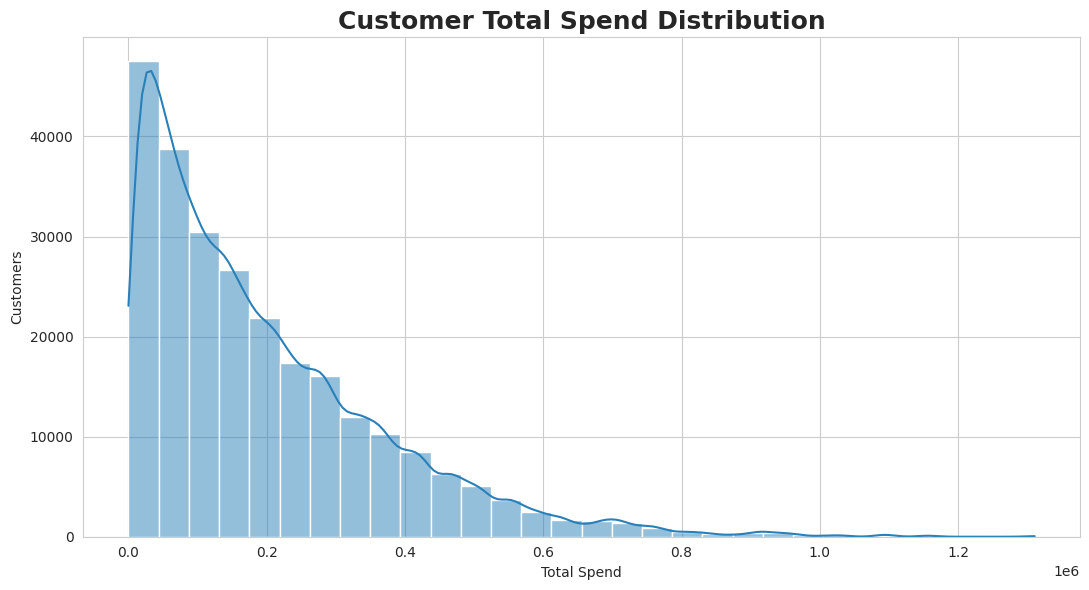

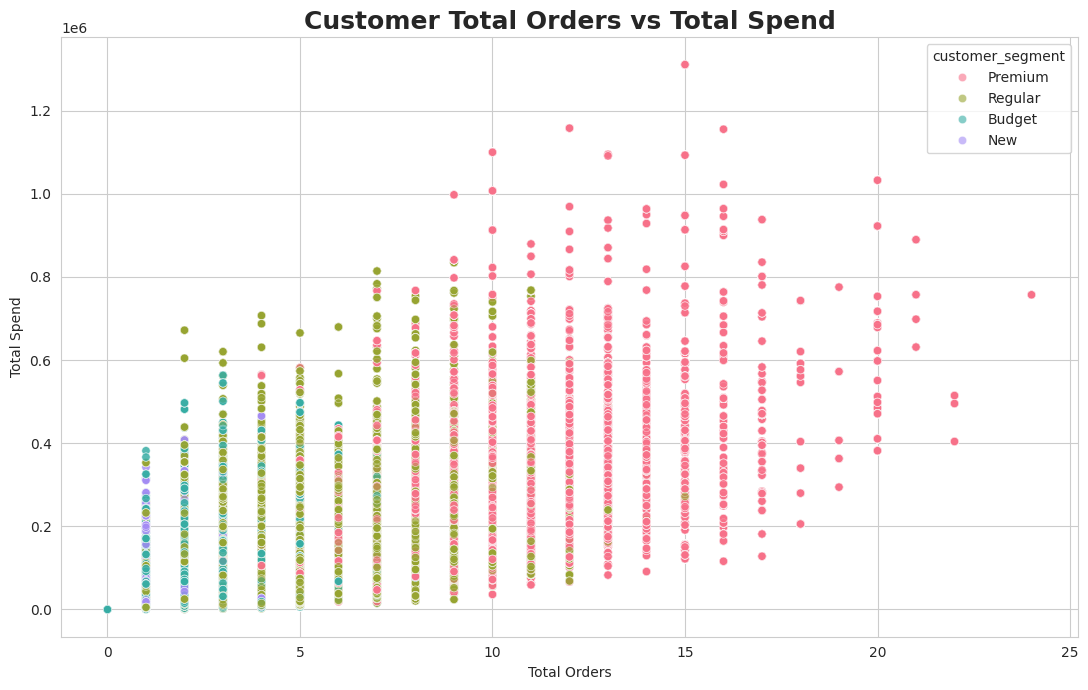

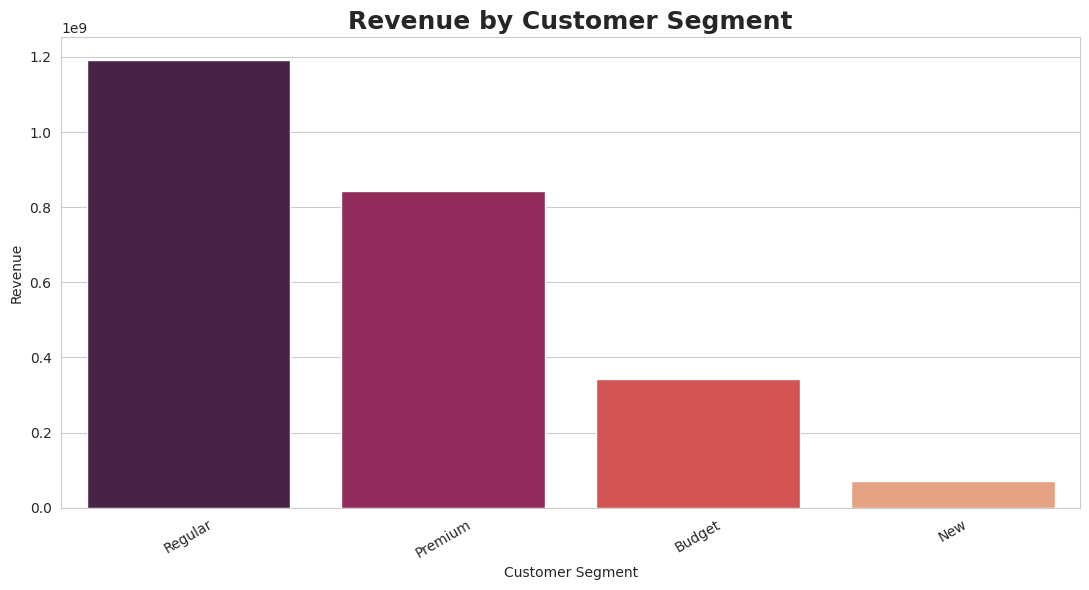

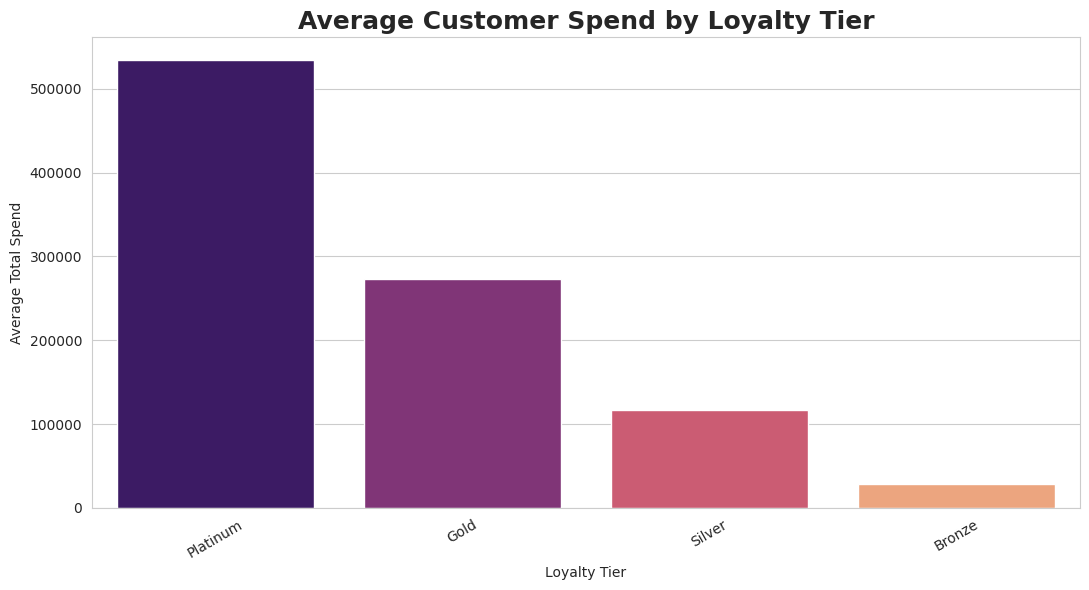

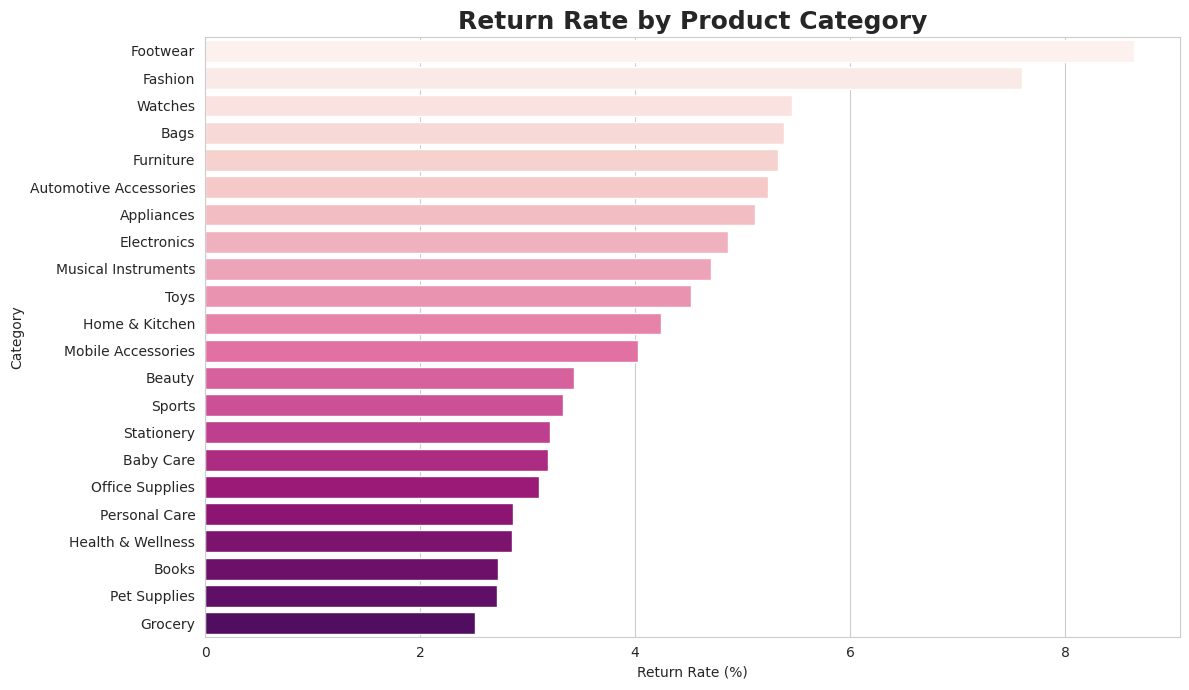

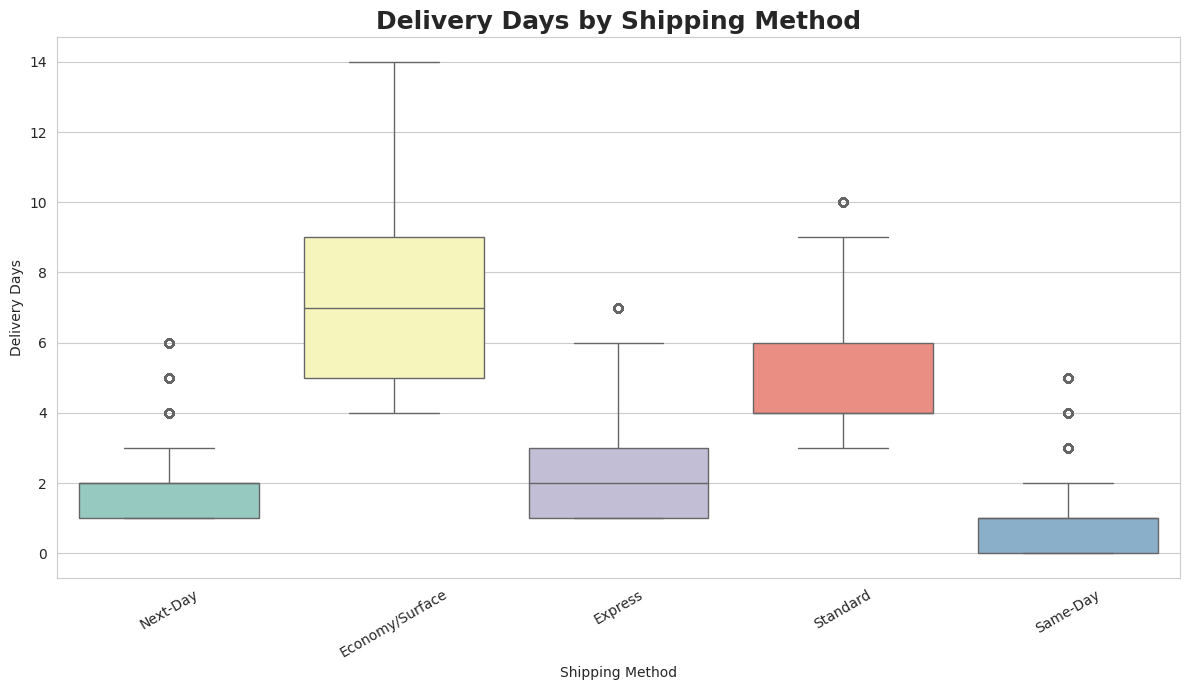

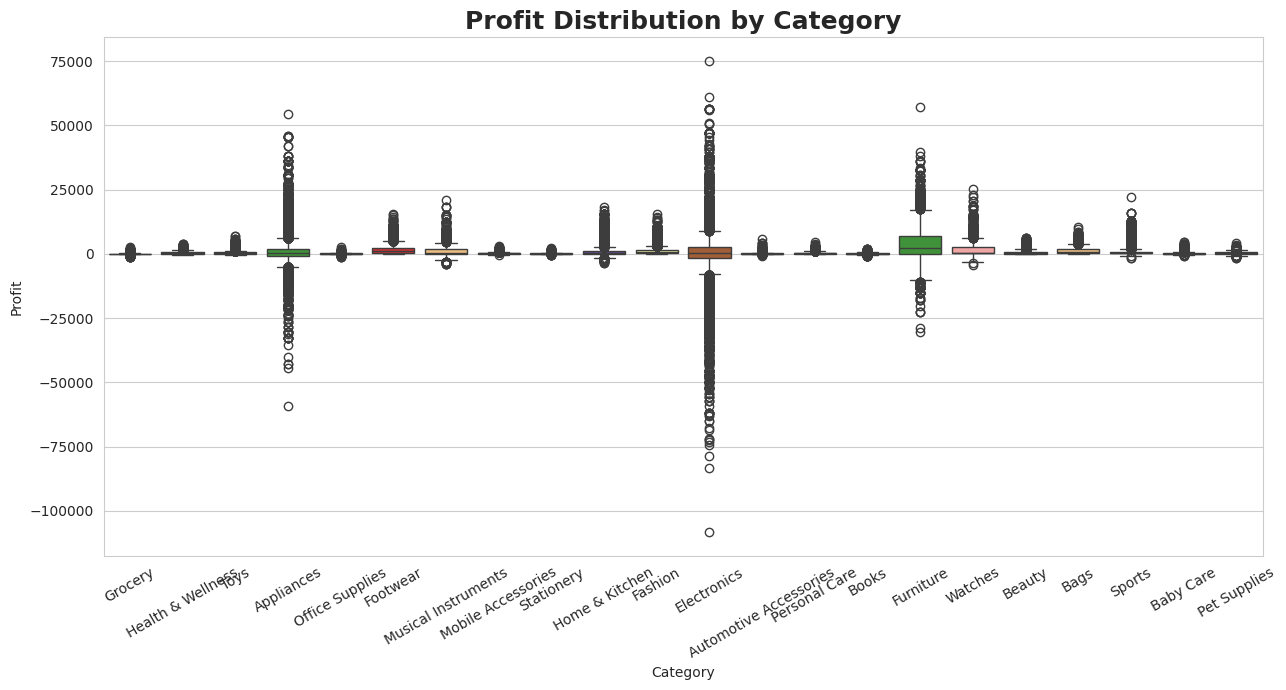


VISUALIZATION / EDA COMPLETED


In [14]:
# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Seaborn style
sns.set_style("whitegrid")

# ============================================================
# 3. MISSING VALUES VISUALIZATION
# ============================================================

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(14, 7))

if len(missing) > 0:
    sns.barplot(
        x=missing.values,
        y=missing.index,
        palette="viridis"
    )

    plt.title(
        "Missing Values by Column",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Missing Values")
    plt.ylabel("Columns")
    plt.tight_layout()
    plt.show()

else:
    print("No missing values found.")


# ============================================================
# 4. DUPLICATE VALUES
# ============================================================

print("\nNumber of duplicate rows:", df.duplicated().sum())

duplicate_count = df.duplicated().sum()
unique_count = len(df) - duplicate_count

plt.figure(figsize=(7, 6))

plt.pie(
    [unique_count, duplicate_count],
    labels=["Unique Rows", "Duplicate Rows"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#3498DB", "#E74C3C"]
)

plt.title(
    "Unique vs Duplicate Records",
    fontsize=16,
    fontweight="bold"
)

plt.show()


# ============================================================
# 5. NUMERICAL COLUMNS
# ============================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumerical Columns:")
print(numeric_columns)


# ============================================================
# 6. HISTOGRAMS FOR IMPORTANT NUMERICAL VARIABLES
# ============================================================

important_numeric = [
    "quantity",
    "unit_price",
    "item_revenue",
    "item_cost",
    "profit",
    "subtotal",
    "shipping_fee",
    "tax_amount",
    "final_amount",
    "total_spend",
    "average_order_value",
    "rating_average",
    "stock_quantity",
    "amount_paid",
    "transaction_fee",
    "refund_amount",
    "delivery_days"
]

available_numeric = [
    col for col in important_numeric
    if col in df.columns
]

for col in available_numeric:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True,
        color="#8E44AD"
    )

    plt.title(
        f"Distribution of {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. BOXPLOTS FOR OUTLIER DETECTION
# ============================================================

box_columns = [
    "quantity",
    "unit_price",
    "item_revenue",
    "profit",
    "final_amount",
    "total_spend",
    "average_order_value",
    "delivery_days"
]

available_box = [
    col for col in box_columns
    if col in df.columns
]

for col in available_box:

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=df[col],
        color="#F39C12"
    )

    plt.title(
        f"Boxplot - {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 8. SALES KPIs
# ============================================================

if "item_revenue" in df.columns:

    total_revenue = df["item_revenue"].sum()
    total_profit = df["profit"].sum() if "profit" in df.columns else 0
    total_quantity = df["quantity"].sum() if "quantity" in df.columns else 0

    print("\n" + "=" * 70)
    print("BUSINESS KPIs")
    print("=" * 70)

    print(f"Total Revenue       : {total_revenue:,.2f}")
    print(f"Total Profit        : {total_profit:,.2f}")
    print(f"Total Quantity      : {total_quantity:,.0f}")

    if "order_id" in df.columns:
        print(f"Unique Orders       : {df['order_id'].nunique():,}")

    if "customer_id" in df.columns:
        print(f"Unique Customers    : {df['customer_id'].nunique():,}")

    if "product_id" in df.columns:
        print(f"Unique Products     : {df['product_id'].nunique():,}")


# ============================================================
# 9. CATEGORY SALES
# ============================================================

if "category" in df.columns and "item_revenue" in df.columns:

    category_sales = (
        df.groupby("category")["item_revenue"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=category_sales.values,
        y=category_sales.index,
        palette="magma"
    )

    plt.title(
        "Revenue by Product Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Revenue")
    plt.ylabel("Category")

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. CATEGORY PROFIT
# ============================================================

if "category" in df.columns and "profit" in df.columns:

    category_profit = (
        df.groupby("category")["profit"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=category_profit.values,
        y=category_profit.index,
        palette="cool"
    )

    plt.title(
        "Profit by Product Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Profit")
    plt.ylabel("Category")

    plt.tight_layout()
    plt.show()


# ============================================================
# 11. SUBCATEGORY SALES
# ============================================================

if "subcategory" in df.columns and "item_revenue" in df.columns:

    subcategory_sales = (
        df.groupby("subcategory")["item_revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=subcategory_sales.values,
        y=subcategory_sales.index,
        palette="plasma"
    )

    plt.title(
        "Top 15 Subcategories by Revenue",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Revenue")
    plt.ylabel("Subcategory")

    plt.tight_layout()
    plt.show()


# ============================================================
# 12. TOP 15 PRODUCTS BY REVENUE
# ============================================================

if "product_name" in df.columns and "item_revenue" in df.columns:

    top_products = (
        df.groupby("product_name")["item_revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(13, 8))

    sns.barplot(
        x=top_products.values,
        y=top_products.index,
        palette="rocket"
    )

    plt.title(
        "Top 15 Products by Revenue",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Revenue")
    plt.ylabel("Product")

    plt.tight_layout()
    plt.show()


# ============================================================
# 13. TOP BRANDS
# ============================================================

if "brand" in df.columns and "item_revenue" in df.columns:

    top_brands = (
        df.groupby("brand")["item_revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=top_brands.values,
        y=top_brands.index,
        palette="Spectral"
    )

    plt.title(
        "Top 15 Brands by Revenue",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Revenue")
    plt.ylabel("Brand")

    plt.tight_layout()
    plt.show()


# ============================================================
# 14. GENDER DISTRIBUTION
# ============================================================

if "gender" in df.columns:

    gender_count = df["gender"].value_counts()

    plt.figure(figsize=(8, 6))

    plt.pie(
        gender_count.values,
        labels=gender_count.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=[
            "#3498DB",
            "#E91E63",
            "#2ECC71",
            "#F1C40F"
        ]
    )

    plt.title(
        "Customer Gender Distribution",
        fontsize=17,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 15. AGE DISTRIBUTION
# ============================================================

if "age" in df.columns:

    plt.figure(figsize=(11, 6))

    sns.histplot(
        df["age"].dropna(),
        bins=20,
        kde=True,
        color="#16A085"
    )

    plt.title(
        "Customer Age Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Age")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# 16. AGE GROUP
# ============================================================

if "age_group" in df.columns:

    age_group = df["age_group"].value_counts()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=age_group.index,
        y=age_group.values,
        palette="Set2"
    )

    plt.title(
        "Customers by Age Group",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Age Group")
    plt.ylabel("Number of Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 17. CUSTOMER SEGMENT
# ============================================================

if "customer_segment" in df.columns:

    segment_count = df["customer_segment"].value_counts()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=segment_count.index,
        y=segment_count.values,
        palette="viridis"
    )

    plt.title(
        "Customer Segment Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Customer Segment")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 18. LOYALTY TIER
# ============================================================

if "loyalty_tier" in df.columns:

    loyalty = df["loyalty_tier"].value_counts()

    plt.figure(figsize=(10, 6))

    plt.pie(
        loyalty.values,
        labels=loyalty.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("Set3", len(loyalty))
    )

    plt.title(
        "Customer Loyalty Tier",
        fontsize=17,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 19. PAYMENT METHOD
# ============================================================

payment_column = None

if "payment_method" in df.columns:
    payment_column = "payment_method"
elif "preferred_payment_method" in df.columns:
    payment_column = "preferred_payment_method"

if payment_column:

    payment_count = df[payment_column].value_counts()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=payment_count.index,
        y=payment_count.values,
        palette="coolwarm"
    )

    plt.title(
        "Payment Method Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Payment Method")
    plt.ylabel("Number of Transactions")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. PAYMENT STATUS
# ============================================================

if "payment_status" in df.columns:

    payment_status = df["payment_status"].value_counts()

    plt.figure(figsize=(9, 6))

    sns.barplot(
        x=payment_status.index,
        y=payment_status.values,
        palette="Set1"
    )

    plt.title(
        "Payment Status",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Payment Status")
    plt.ylabel("Transactions")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 21. ORDER STATUS
# ============================================================

if "order_status" in df.columns:

    order_status = df["order_status"].value_counts()

    plt.figure(figsize=(10, 6))

    plt.pie(
        order_status.values,
        labels=order_status.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("tab10", len(order_status))
    )

    plt.title(
        "Order Status Distribution",
        fontsize=17,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 22. SHIPPING METHOD
# ============================================================

if "shipping_method" in df.columns:

    shipping = df["shipping_method"].value_counts()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=shipping.index,
        y=shipping.values,
        palette="Accent"
    )

    plt.title(
        "Shipping Method Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Shipping Method")
    plt.ylabel("Orders")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 23. MARKETING CHANNEL
# ============================================================

if "marketing_channel" in df.columns:

    marketing = df["marketing_channel"].value_counts()

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=marketing.index,
        y=marketing.values,
        palette="husl"
    )

    plt.title(
        "Marketing Channel Performance",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Marketing Channel")
    plt.ylabel("Number of Orders")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 24. ACQUISITION CHANNEL
# ============================================================

if "acquisition_channel" in df.columns:

    acquisition = df["acquisition_channel"].value_counts()

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=acquisition.index,
        y=acquisition.values,
        palette="cubehelix"
    )

    plt.title(
        "Customer Acquisition Channel",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Acquisition Channel")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 25. DEVICE PREFERENCE
# ============================================================

if "preferred_device" in df.columns:

    device = df["preferred_device"].value_counts()

    plt.figure(figsize=(9, 6))

    plt.pie(
        device.values,
        labels=device.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("pastel", len(device))
    )

    plt.title(
        "Customer Preferred Device",
        fontsize=17,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 26. DELIVERY STATUS
# ============================================================

if "delivery_status" in df.columns:

    delivery_status = df["delivery_status"].value_counts()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=delivery_status.index,
        y=delivery_status.values,
        palette="RdYlGn"
    )

    plt.title(
        "Delivery Status",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Delivery Status")
    plt.ylabel("Shipments")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 27. DELAYED FLAG
# ============================================================

if "delayed_flag" in df.columns:

    delayed = df["delayed_flag"].value_counts()

    plt.figure(figsize=(8, 6))

    plt.pie(
        delayed.values,
        labels=delayed.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#2ECC71", "#E74C3C"]
    )

    plt.title(
        "Delayed vs On-Time Deliveries",
        fontsize=17,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 28. DELIVERY DAYS DISTRIBUTION
# ============================================================

if "delivery_days" in df.columns:

    plt.figure(figsize=(11, 6))

    sns.histplot(
        df["delivery_days"].dropna(),
        bins=20,
        kde=True,
        color="#E67E22"
    )

    plt.title(
        "Delivery Days Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Delivery Days")
    plt.ylabel("Number of Shipments")

    plt.tight_layout()
    plt.show()


# ============================================================
# 29. RETURNS ANALYSIS
# ============================================================

if "is_returned" in df.columns:

    returned = df["is_returned"].value_counts()

    plt.figure(figsize=(8, 6))

    plt.pie(
        returned.values,
        labels=returned.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#3498DB", "#E74C3C"]
    )

    plt.title(
        "Returned vs Non-Returned Products",
        fontsize=17,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 30. RETURN REASONS
# ============================================================

if "return_reason" in df.columns:

    return_reason = (
        df["return_reason"]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=return_reason.values,
        y=return_reason.index,
        palette="flare"
    )

    plt.title(
        "Top Return Reasons",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Returns")
    plt.ylabel("Return Reason")

    plt.tight_layout()
    plt.show()


# ============================================================
# 31. RETURN STATUS
# ============================================================

if "return_status" in df.columns:

    return_status = df["return_status"].value_counts()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=return_status.index,
        y=return_status.values,
        palette="mako"
    )

    plt.title(
        "Return Status",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Return Status")
    plt.ylabel("Returns")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 32. TOP DELIVERY CITIES
# ============================================================

city_column = None

if "delivery_city" in df.columns:
    city_column = "delivery_city"
elif "city" in df.columns:
    city_column = "city"

if city_column:

    top_cities = (
        df[city_column]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 8))

    sns.barplot(
        x=top_cities.values,
        y=top_cities.index,
        palette="Spectral"
    )

    plt.title(
        "Top 15 Cities by Orders",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Orders")
    plt.ylabel("City")

    plt.tight_layout()
    plt.show()


# ============================================================
# 33. STATE-WISE SALES
# ============================================================

if "state" in df.columns and "item_revenue" in df.columns:

    state_sales = (
        df.groupby("state")["item_revenue"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(12, 8))

    sns.barplot(
        x=state_sales.values,
        y=state_sales.index,
        palette="viridis"
    )

    plt.title(
        "Top 15 States by Revenue",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Revenue")
    plt.ylabel("State")

    plt.tight_layout()
    plt.show()


# ============================================================
# 34. MONTHLY SALES TREND
# ============================================================

if "order_date" in df.columns and "item_revenue" in df.columns:

    df["order_date"] = pd.to_datetime(
        df["order_date"],
        errors="coerce"
    )

    monthly_sales = (
        df.dropna(subset=["order_date"])
        .set_index("order_date")
        .resample("M")["item_revenue"]
        .sum()
    )

    plt.figure(figsize=(14, 6))

    plt.plot(
        monthly_sales.index,
        monthly_sales.values,
        marker="o",
        linewidth=3,
        color="#9B59B6"
    )

    plt.fill_between(
        monthly_sales.index,
        monthly_sales.values,
        alpha=0.2,
        color="#9B59B6"
    )

    plt.title(
        "Monthly Revenue Trend",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Month")
    plt.ylabel("Revenue")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 35. MONTHLY PROFIT TREND
# ============================================================

if "order_date" in df.columns and "profit" in df.columns:

    monthly_profit = (
        df.dropna(subset=["order_date"])
        .set_index("order_date")
        .resample("M")["profit"]
        .sum()
    )

    plt.figure(figsize=(14, 6))

    plt.plot(
        monthly_profit.index,
        monthly_profit.values,
        marker="o",
        linewidth=3,
        color="#27AE60"
    )

    plt.title(
        "Monthly Profit Trend",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Month")
    plt.ylabel("Profit")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 36. DISCOUNT VS REVENUE
# ============================================================

discount_column = None

if "discount_percentage_x" in df.columns:
    discount_column = "discount_percentage_x"
elif "discount_percentage_y" in df.columns:
    discount_column = "discount_percentage_y"

if discount_column and "item_revenue" in df.columns:

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=df,
        x=discount_column,
        y="item_revenue",
        hue="category" if "category" in df.columns else None,
        alpha=0.6,
        palette="tab10"
    )

    plt.title(
        "Discount Percentage vs Revenue",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Discount Percentage")
    plt.ylabel("Item Revenue")

    plt.tight_layout()
    plt.show()


# ============================================================
# 37. QUANTITY VS PROFIT
# ============================================================

if "quantity" in df.columns and "profit" in df.columns:

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=df,
        x="quantity",
        y="profit",
        hue="category" if "category" in df.columns else None,
        alpha=0.6,
        palette="Set1"
    )

    plt.title(
        "Quantity vs Profit",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Quantity")
    plt.ylabel("Profit")

    plt.tight_layout()
    plt.show()


# ============================================================
# 38. PRICE VS RATING
# ============================================================

if "price" in df.columns and "rating_average" in df.columns:

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=df,
        x="price",
        y="rating_average",
        hue="category" if "category" in df.columns else None,
        alpha=0.6,
        palette="Dark2"
    )

    plt.title(
        "Product Price vs Rating",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Product Price")
    plt.ylabel("Average Rating")

    plt.tight_layout()
    plt.show()


# ============================================================
# 39. STOCK QUANTITY BY CATEGORY
# ============================================================

if "category" in df.columns and "stock_quantity" in df.columns:

    stock_category = (
        df.groupby("category")["stock_quantity"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=stock_category.values,
        y=stock_category.index,
        palette="YlGnBu"
    )

    plt.title(
        "Average Stock Quantity by Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Average Stock Quantity")
    plt.ylabel("Category")

    plt.tight_layout()
    plt.show()


# ============================================================
# 40. CORRELATION HEATMAP
# ============================================================

corr_columns = [
    "quantity",
    "unit_price",
    "item_revenue",
    "item_cost",
    "profit",
    "subtotal",
    "shipping_fee",
    "tax_amount",
    "final_amount",
    "age",
    "total_orders",
    "total_spend",
    "average_order_value",
    "price",
    "cost_price",
    "rating_average",
    "rating_count",
    "stock_quantity",
    "amount_paid",
    "transaction_fee",
    "refund_amount",
    "delivery_days"
]

corr_columns = [
    col for col in corr_columns
    if col in df.columns
]

corr = df[corr_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    center=0
)

plt.title(
    "Correlation Heatmap of Numerical Variables",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 41. REVENUE VS PROFIT
# ============================================================

if "item_revenue" in df.columns and "profit" in df.columns:

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=df,
        x="item_revenue",
        y="profit",
        hue="category" if "category" in df.columns else None,
        size="quantity" if "quantity" in df.columns else None,
        sizes=(20, 250),
        alpha=0.65,
        palette="Spectral"
    )

    plt.title(
        "Revenue vs Profit",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Revenue")
    plt.ylabel("Profit")

    plt.tight_layout()
    plt.show()


# ============================================================
# 42. CUSTOMER SPEND DISTRIBUTION
# ============================================================

if "total_spend" in df.columns:

    plt.figure(figsize=(11, 6))

    sns.histplot(
        df["total_spend"].dropna(),
        bins=30,
        kde=True,
        color="#2980B9"
    )

    plt.title(
        "Customer Total Spend Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Total Spend")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# 43. TOTAL ORDERS VS TOTAL SPEND
# ============================================================

if "total_orders" in df.columns and "total_spend" in df.columns:

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=df,
        x="total_orders",
        y="total_spend",
        hue="customer_segment"
        if "customer_segment" in df.columns else None,
        alpha=0.6,
        palette="husl"
    )

    plt.title(
        "Customer Total Orders vs Total Spend",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Total Orders")
    plt.ylabel("Total Spend")

    plt.tight_layout()
    plt.show()


# ============================================================
# 44. CUSTOMER SEGMENT VS REVENUE
# ============================================================

if "customer_segment" in df.columns and "item_revenue" in df.columns:

    segment_revenue = (
        df.groupby("customer_segment")["item_revenue"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=segment_revenue.index,
        y=segment_revenue.values,
        palette="rocket"
    )

    plt.title(
        "Revenue by Customer Segment",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Customer Segment")
    plt.ylabel("Revenue")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 45. LOYALTY TIER VS SPEND
# ============================================================

if "loyalty_tier" in df.columns and "total_spend" in df.columns:

    loyalty_spend = (
        df.groupby("loyalty_tier")["total_spend"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=loyalty_spend.index,
        y=loyalty_spend.values,
        palette="magma"
    )

    plt.title(
        "Average Customer Spend by Loyalty Tier",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Loyalty Tier")
    plt.ylabel("Average Total Spend")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 46. RETURN RATE BY CATEGORY
# ============================================================

if "category" in df.columns and "is_returned" in df.columns:

    return_rate = (
        df.groupby("category")["is_returned"]
        .mean()
        .sort_values(ascending=False)
    ) * 100

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=return_rate.values,
        y=return_rate.index,
        palette="RdPu"
    )

    plt.title(
        "Return Rate by Product Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Return Rate (%)")
    plt.ylabel("Category")

    plt.tight_layout()
    plt.show()


# ============================================================
# 47. DELIVERY DAYS BY SHIPPING METHOD
# ============================================================

if "shipping_method" in df.columns and "delivery_days" in df.columns:

    plt.figure(figsize=(12, 7))

    sns.boxplot(
        data=df,
        x="shipping_method",
        y="delivery_days",
        palette="Set3"
    )

    plt.title(
        "Delivery Days by Shipping Method",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Shipping Method")
    plt.ylabel("Delivery Days")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 48. CATEGORY VS PROFIT - BOXPLOT
# ============================================================

if "category" in df.columns and "profit" in df.columns:

    plt.figure(figsize=(13, 7))

    sns.boxplot(
        data=df,
        x="category",
        y="profit",
        palette="Paired"
    )

    plt.title(
        "Profit Distribution by Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Category")
    plt.ylabel("Profit")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 49. INTERACTIVE PLOTLY CATEGORY REVENUE
# ============================================================

if "category" in df.columns and "item_revenue" in df.columns:

    category_plotly = (
        df.groupby("category", as_index=False)["item_revenue"]
        .sum()
        .sort_values("item_revenue", ascending=False)
    )

    fig = px.bar(
        category_plotly,
        x="category",
        y="item_revenue",
        color="category",
        title="Interactive Revenue by Category",
        text_auto=".2s",
        color_discrete_sequence=px.colors.qualitative.Bold
    )

    fig.update_layout(
        template="plotly_white",
        title_x=0.5
    )

    fig.show()


# ============================================================
# 50. INTERACTIVE MONTHLY REVENUE
# ============================================================

if "order_date" in df.columns and "item_revenue" in df.columns:

    monthly_plotly = (
        df.dropna(subset=["order_date"])
        .groupby(
            df["order_date"].dt.to_period("M")
        )["item_revenue"]
        .sum()
        .reset_index()
    )

    monthly_plotly["order_date"] = (
        monthly_plotly["order_date"]
        .astype(str)
    )

    fig = px.line(
        monthly_plotly,
        x="order_date",
        y="item_revenue",
        markers=True,
        title="Interactive Monthly Revenue Trend"
    )

    fig.update_traces(
        line=dict(width=3)
    )

    fig.update_layout(
        template="plotly_dark",
        title_x=0.5,
        xaxis_title="Month",
        yaxis_title="Revenue"
    )

    fig.show()


# ============================================================
# 51. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("VISUALIZATION / EDA COMPLETED")
print("=" * 70)

## Feature engineering

ORIGINAL DATASET
Shape: (254405, 78)


,order_item_id,order_id,product_id,quantity,unit_price,discount_percentage_x,item_revenue,item_cost,profit,customer_id,order_date,order_time,order_status,shipping_method,delivery_city,delivery_state,coupon_code,discount_percentage_y,marketing_channel,subtotal,shipping_fee,tax_amount,final_amount,campaign_id,customer_signup_date,gender,age,age_group,state,city,pincode_prefix,customer_segment,preferred_device,preferred_payment_method,acquisition_channel,total_orders,total_spend,last_order_date,average_order_value,customer_status,loyalty_tier,product_name,category,subcategory,brand,price,cost_price,discount_range,rating_average,rating_count,stock_quantity,product_launch_date,product_type,return_rate_baseline,payment_id,payment_date,payment_method,payment_status,amount_paid,transaction_fee,refund_amount,shipment_id,warehouse_city,delivery_city_ship,shipping_method_ship,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_days,delivery_status,delayed_flag,return_id,customer_id_ret,return_date,return_reason,refund_amount_ret,return_status,is_returned
0,OI10000000,ORD1000000,PROD10347,4,150.0,6.5,561.0,515.92,45.08,CUST103868,2025-08-16,22:35:23,Failed,Next-Day,Mumbai,Maharashtra,FEST20,5.0,SMS Marketing,14439.9,0.0,722.0,15161.9,Unknown,2025-02-23,Female,29.0,25-34,Uttar Pradesh,Noida,217,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,2025-12-31,37637.53,Active,Platinum,"Murthy, Basic Beverage",Grocery,Beverages,"Murthy,",150.0,128.98,30-45%,3.9,118,2078,2023-01-23,Standard,0.0111,PAY1000000,2025-08-16,EMI,Failed,0.0,0.0,0.0,Unknown,Unknown,Unknown,Unknown,NaT,NaT,NaT,4.0,Unknown,0.0,Unknown,Unknown,NaT,Unknown,1969.1,Unknown,0
1,OI10000001,ORD1000000,PROD10510,1,1150.0,5.0,1092.5,752.18,340.32,CUST103868,2025-08-16,22:35:23,Failed,Next-Day,Mumbai,Maharashtra,FEST20,5.0,SMS Marketing,14439.9,0.0,722.0,15161.9,Unknown,2025-02-23,Female,29.0,25-34,Uttar Pradesh,Noida,217,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,2025-12-31,37637.53,Active,Platinum,"Iyer, Deluxe Supplement",Health & Wellness,Supplements,"Iyer,",1150.0,752.18,20-35%,3.7,1107,2987,2024-09-09,Budget,0.0316,PAY1000000,2025-08-16,EMI,Failed,0.0,0.0,0.0,Unknown,Unknown,Unknown,Unknown,NaT,NaT,NaT,4.0,Unknown,0.0,Unknown,Unknown,NaT,Unknown,1969.1,Unknown,0
2,OI10000002,ORD1000000,PROD10305,2,960.0,8.0,1766.4,1217.66,548.74,CUST103868,2025-08-16,22:35:23,Failed,Next-Day,Mumbai,Maharashtra,FEST20,5.0,SMS Marketing,14439.9,0.0,722.0,15161.9,Unknown,2025-02-23,Female,29.0,25-34,Uttar Pradesh,Noida,217,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,2025-12-31,37637.53,Active,Platinum,Patla-Gaba Advanced Soft Toy,Toys,Soft Toys,Patla-Gaba,960.0,608.83,5-20%,4.3,156,2026,2023-03-29,Standard,0.0971,PAY1000000,2025-08-16,EMI,Failed,0.0,0.0,0.0,Unknown,Unknown,Unknown,Unknown,NaT,NaT,NaT,4.0,Unknown,0.0,Unknown,Unknown,NaT,Unknown,1969.1,Unknown,0
3,OI10000003,ORD1000000,PROD10092,4,920.0,5.0,3496.0,3049.52,446.48,CUST103868,2025-08-16,22:35:23,Failed,Next-Day,Mumbai,Maharashtra,FEST20,5.0,SMS Marketing,14439.9,0.0,722.0,15161.9,Unknown,2025-02-23,Female,29.0,25-34,Uttar Pradesh,Noida,217,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,2025-12-31,37637.53,Active,Platinum,"Mittal, Premium Snack",Grocery,Snacks,"Mittal,",920.0,762.38,0-15%,3.3,361,2994,2024-12-19,Standard,0.0122,PAY1000000,2025-08-16,EMI,Failed,0.0,0.0,0.0,Unknown,Unknown,Unknown,Unknown,NaT,NaT,NaT,4.0,Unknown,0.0,Unknown,Unknown,NaT,Unknown,1969.1,Unknown,0
4,OI10000004,ORD1000000,PROD10417,3,2640.0,5.0,7524.0,6847.65,676.35,CUST103868,2025-08-16,22:35:23,Failed,Next-Day,Mumbai,Maharashtra,FEST20,5.0,SMS Marketing,14439.9,0.0,722.0,15161.9,Unknown,2025-02-23,Female,29.0,25-34,Uttar Pradesh,Noida,217,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,2025-12-31,37637.53,Active,Platinum,Goda Ultra Air Conditioner,Appliances,Air Conditioners,Goda,2640.0,2282.55,20-35%,3.8,1326,684,2023-10-30,Standard,0.0838,PAY1000000,2025-08-16,EMI,Failed,0.0,0.0,0.0,Unknown,Unknown,Unkno


Duplicate rows: 0
Shape after removing duplicates: (254405, 78)

Target column: is_returned

Original target values:
is_returned
0    242154
1     12251
Name: count, dtype: int64

Cleaned target values:
is_returned
0    242154
1     12251
Name: count, dtype: int64

Target classes:
[0 1]


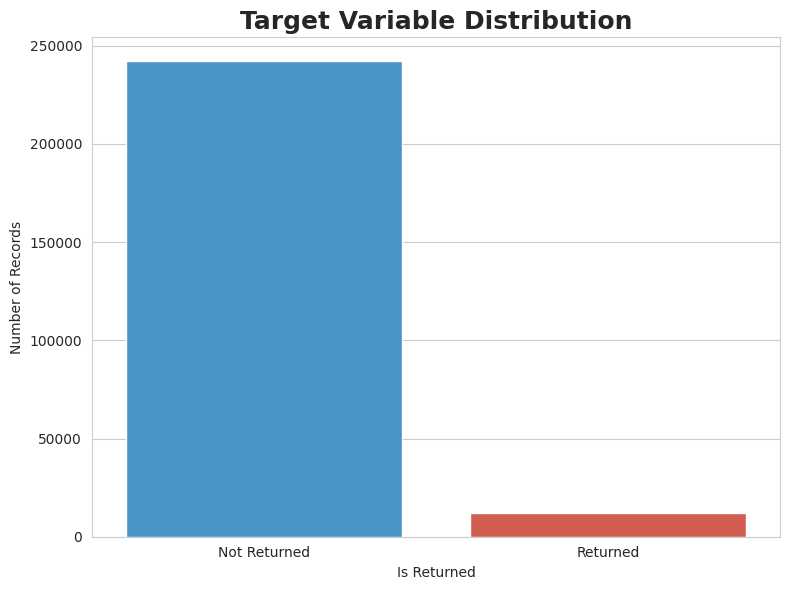


Removed ID columns:
['order_item_id', 'order_id', 'product_id', 'customer_id', 'payment_id', 'shipment_id', 'return_id', 'customer_id_ret', 'campaign_id']

Removed redundant columns:
['discount_percentage_y', 'delivery_city_ship', 'shipping_method_ship', 'refund_amount_ret']

DATA AFTER PREPROCESSING
Shape: (254405, 92)


,quantity,unit_price,discount_percentage_x,item_revenue,item_cost,profit,order_status,shipping_method,delivery_city,delivery_state,coupon_code,marketing_channel,subtotal,shipping_fee,tax_amount,final_amount,gender,age,age_group,state,city,pincode_prefix,customer_segment,preferred_device,preferred_payment_method,acquisition_channel,total_orders,total_spend,average_order_value,customer_status,loyalty_tier,product_name,category,subcategory,brand,price,cost_price,discount_range,rating_average,rating_count,stock_quantity,product_type,return_rate_baseline,payment_method,payment_status,amount_paid,transaction_fee,refund_amount,warehouse_city,delivery_days,delivery_status,delayed_flag,return_reason,return_status,is_returned,order_date_year,order_date_month,order_date_day,order_date_dayofweek,customer_signup_date_year,customer_signup_date_month,customer_signup_date_day,customer_signup_date_dayofweek,last_order_date_year,last_order_date_month,last_order_date_day,last_order_date_dayofweek,product_launch_date_year,product_launch_date_month,product_launch_date_day,product_launch_date_dayofweek,payment_date_year,payment_date_month,payment_date_day,payment_date_dayofweek,dispatch_date_year,dispatch_date_month,dispatch_date_day,dispatch_date_dayofweek,expected_delivery_date_year,expected_delivery_date_month,expected_delivery_date_day,expected_delivery_date_dayofweek,actual_delivery_date_year,actual_delivery_date_month,actual_delivery_date_day,actual_delivery_date_dayofweek,return_date_year,return_date_month,return_date_day,return_date_dayofweek,order_hour
0,4,150.0,6.5,561.0,515.92,45.08,Failed,Next-Day,Mumbai,Maharashtra,FEST20,SMS Marketing,14439.9,0.0,722.0,15161.9,Female,29.0,25-34,Uttar Pradesh,Noida,217,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,37637.53,Active,Platinum,"Murthy, Basic Beverage",Grocery,Beverages,"Murthy,",150.0,128.98,30-45%,3.9,118,2078,Standard,0.0111,EMI,Failed,0.0,0.0,0.0,Unknown,4.0,Unknown,0.0,Unknown,Unknown,0,2025,8,16,5,2025,2,23,6,2025.0,12.0,31.0,2.0,2023,1,23,0,2025,8,16,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
1,1,1150.0,5.0,1092.5,752.18,340.32,Failed,Next-Day,Mumbai,Maharashtra,FEST20,SMS Marketing,14439.9,0.0,722.0,15161.9,Female,29.0,25-34,Uttar Pradesh,Noida,217,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,37637.53,Active,Platinum,"Iyer, Deluxe Supplement",Health & Wellness,Supplements,"Iyer,",1150.0,752.18,20-35%,3.7,1107,2987,Budget,0.0316,EMI,Failed,0.0,0.0,0.0,Unknown,4.0,Unknown,0.0,Unknown,Unknown,0,2025,8,16,5,2025,2,23,6,2025.0,12.0,31.0,2.0,2024,9,9,0,2025,8,16,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
2,2,960.0,8.0,1766.4,1217.66,548.74,Failed,Next-Day,Mumbai,Maharashtra,FEST20,SMS Marketing,14439.9,0.0,722.0,15161.9,Female,29.0,25-34,Uttar Pradesh,Noida,217,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,37637.53,Active,Platinum,Patla-Gaba Advanced Soft Toy,Toys,Soft Toys,Patla-Gaba,960.0,608.83,5-20%,4.3,156,2026,Standard,0.0971,EMI,Failed,0.0,0.0,0.0,Unknown,4.0,Unknown,0.0,Unknown,Unknown,0,2025,8,16,5,2025,2,23,6,2025.0,12.0,31.0,2.0,2023,3,29,2,2025,8,16,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
3,4,920.0,5.0,3496.0,3049.52,446.48,Failed,Next-Day,Mumbai,Maharashtra,FEST20,SMS Marketing,14439.9,0.0,722.0,15161.9,Female,29.0,25-34,Uttar Pradesh,Noida,217,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,37637.53,Active,Platinum,"Mittal, Premium Snack",Grocery,Snacks,"Mittal,",920.0,762.38,0-15%,3.3,361,2994,Standard,0.0122,EMI,Failed,0.0,0.0,0.0,Unknown,4.0,Unknown,0.0,Unknown,Unknown,0,2025,8,16,5,2025,2,23,6,2025.0,12.0,31.0,2.0,2024,12,19,3,2025,8,16,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
4,3,2640.0,5.0,7524.0,6847.65,676.35,Failed,Next-Day,Mumbai,Maharashtra,FEST20,SMS Marketing,14439.9,0.0,722.0,15161.9,Female,29.0,25-34,Uttar Pradesh,Noida,217,Premium,Desktop,Debit Card,SMS Marketing,12,451650.38,37637.53,Active,Platinum,Goda Ultra Air Conditi


X Shape: (254405, 91)
y Shape: (254405,)

Constant columns:
[]

Numerical features:
['quantity', 'unit_price', 'discount_percentage_x', 'item_revenue', 'item_cost', 'profit', 'subtotal', 'shipping_fee', 'tax_amount', 'final_amount', 'age', 'pincode_prefix', 'total_orders', 'total_spend', 'average_order_value', 'price', 'cost_price', 'rating_average', 'rating_count', 'stock_quantity', 'return_rate_baseline', 'amount_paid', 'transaction_fee', 'refund_amount', 'delivery_days', 'delayed_flag', 'order_date_year', 'order_date_month', 'order_date_day', 'order_date_dayofweek', 'customer_signup_date_year', 'customer_signup_date_month', 'customer_signup_date_day', 'customer_signup_date_dayofweek', 'last_order_date_year', 'last_order_date_month', 'last_order_date_day', 'last_order_date_dayofweek', 'product_launch_date_year', 'product_launch_date_month', 'product_launch_date_day', 'product_launch_date_dayofweek', 'payment_date_year', 'payment_date_month', 'payment_date_day', 'payment_date_dayofwe

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,100.00%,100.00%,100.00%,100.00%,1.0000
1,Random Forest,100.00%,100.00%,100.00%,100.00%,1.0000
2,Gradient Boosting,100.00%,100.00%,100.00%,100.00%,1.0000
3,Extra Trees,100.00%,100.00%,100.00%,100.00%,1.0000
4,XGBoost,100.00%,100.00%,100.00%,100.00%,1.0000
5,SVM,100.00%,100.00%,99.96%,99.98%,1.0000
6,Logistic Regression,100.00%,100.00%,99.92%,99.96%,1.0000
7,KNN,99.85%,100.00%,96.94%,98.45%,0.9933


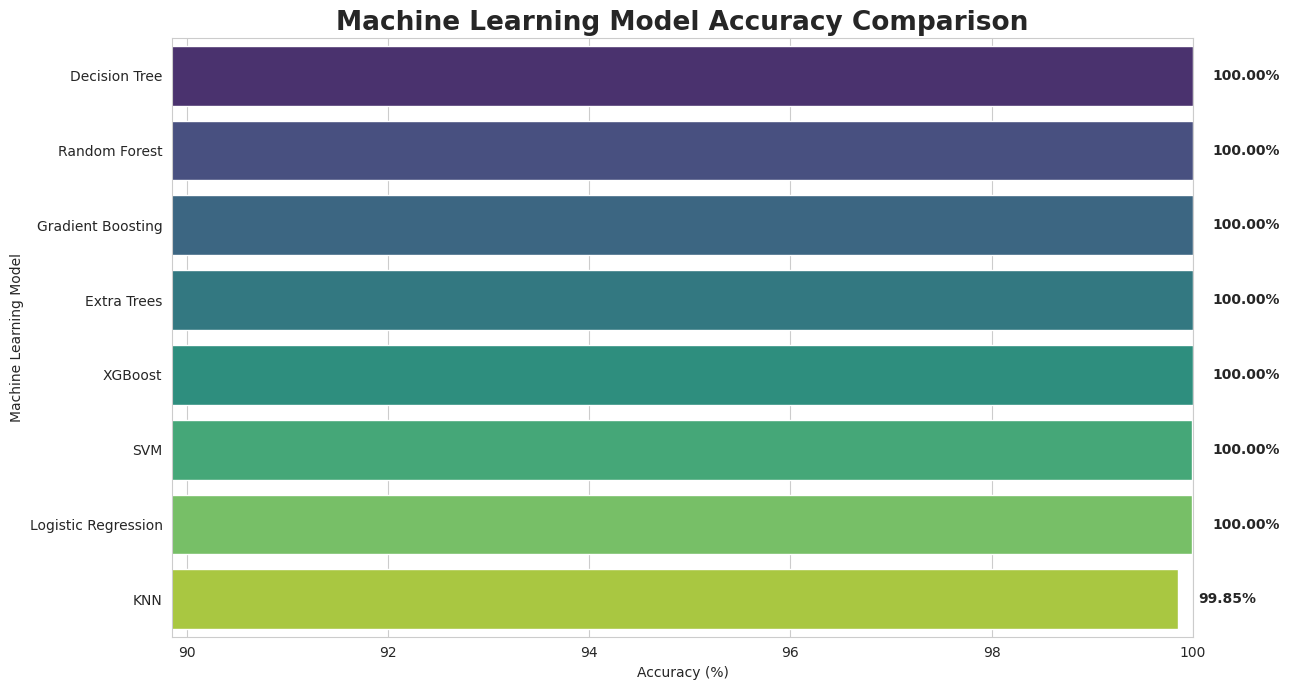

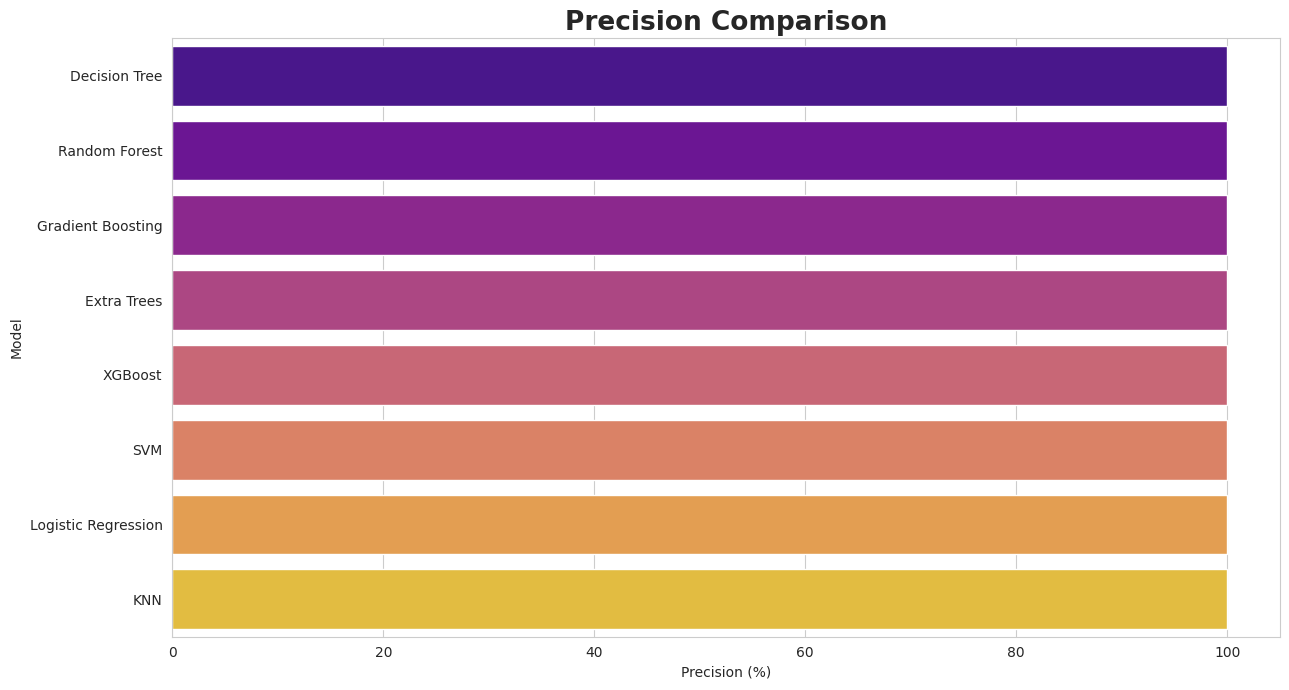

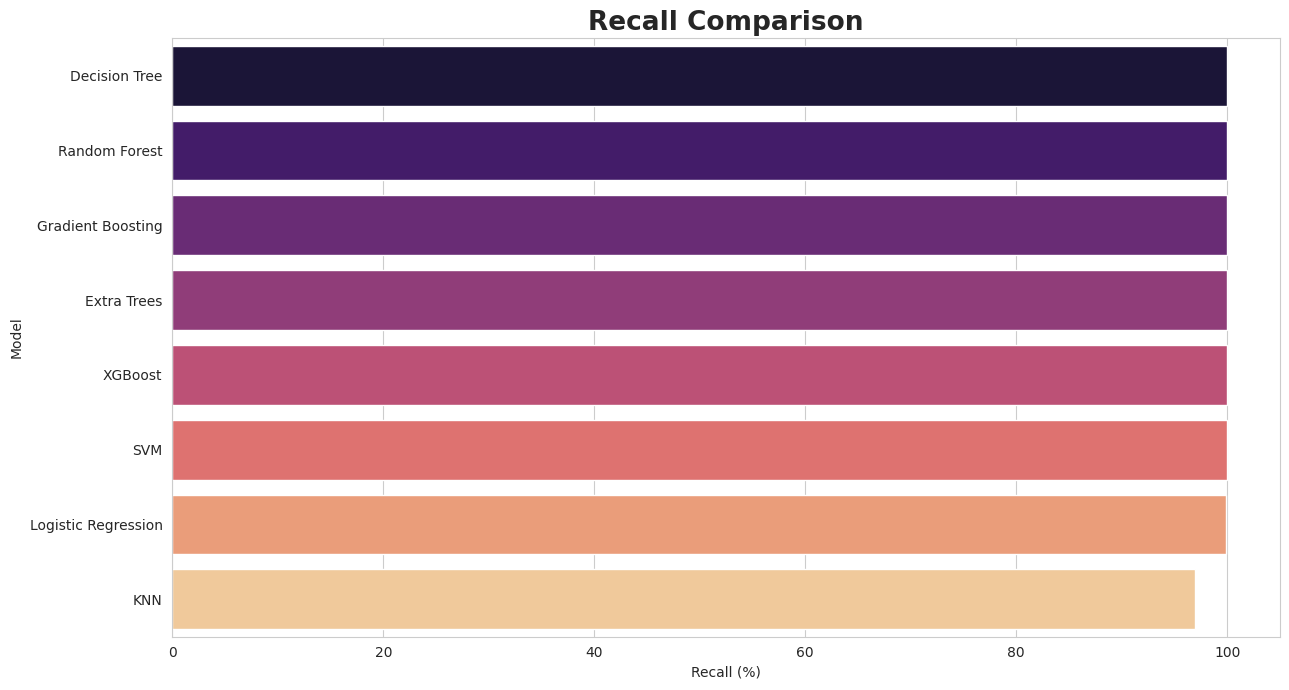

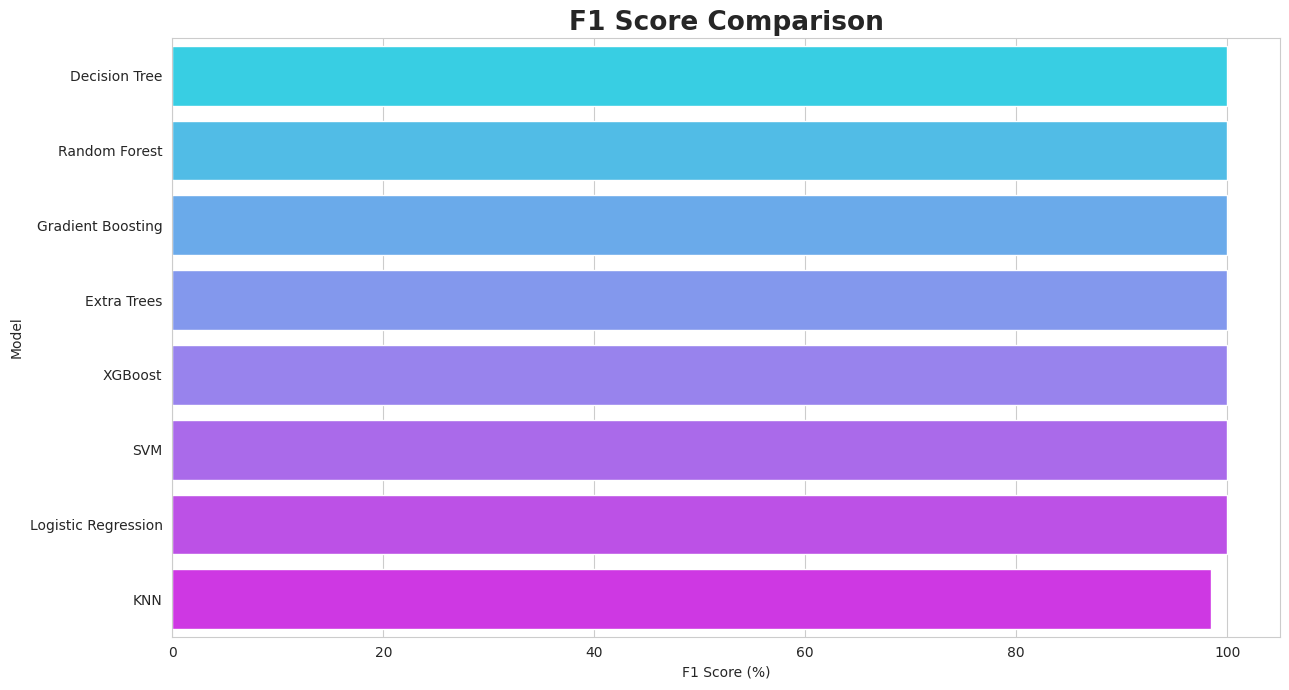


CONFUSION MATRICES


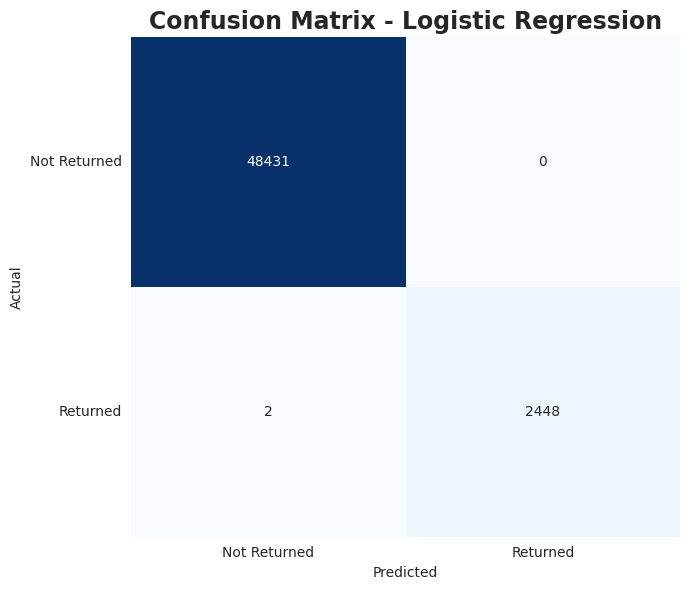

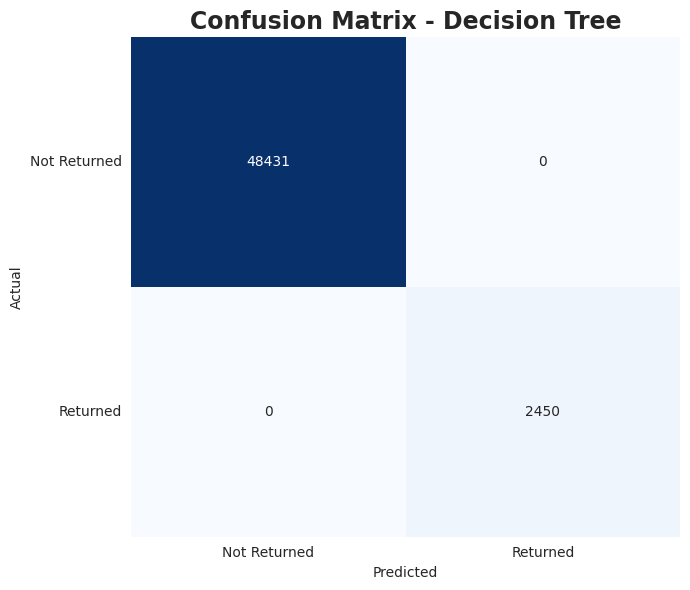

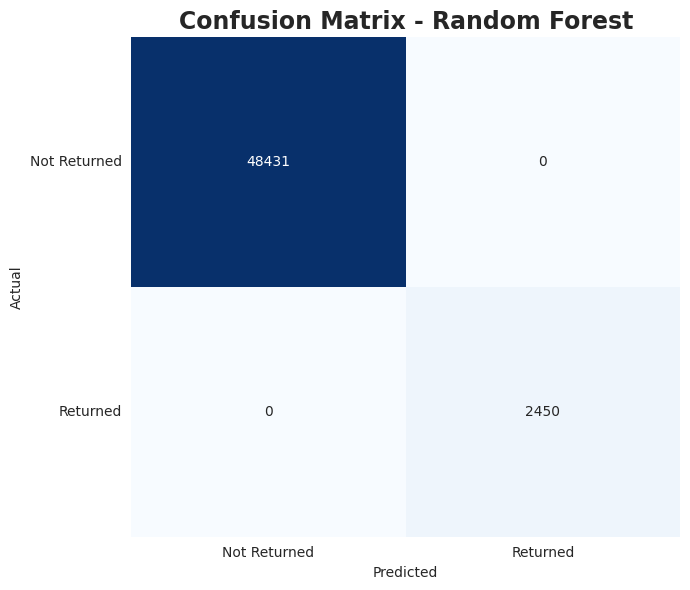

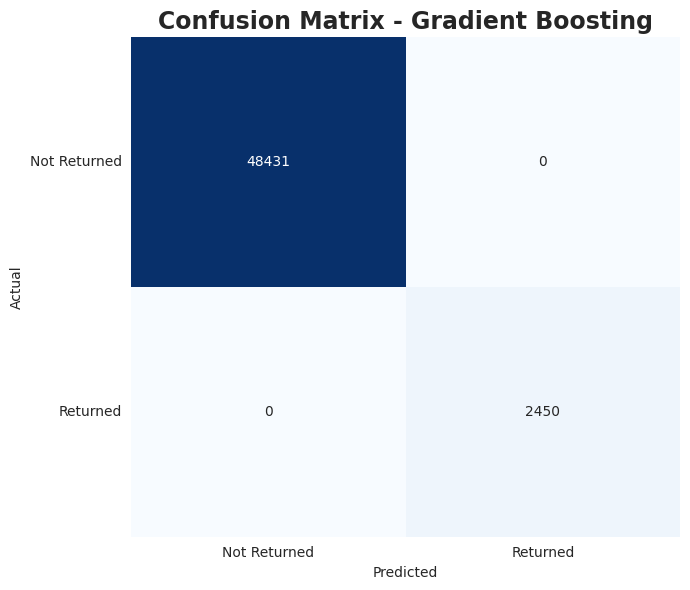

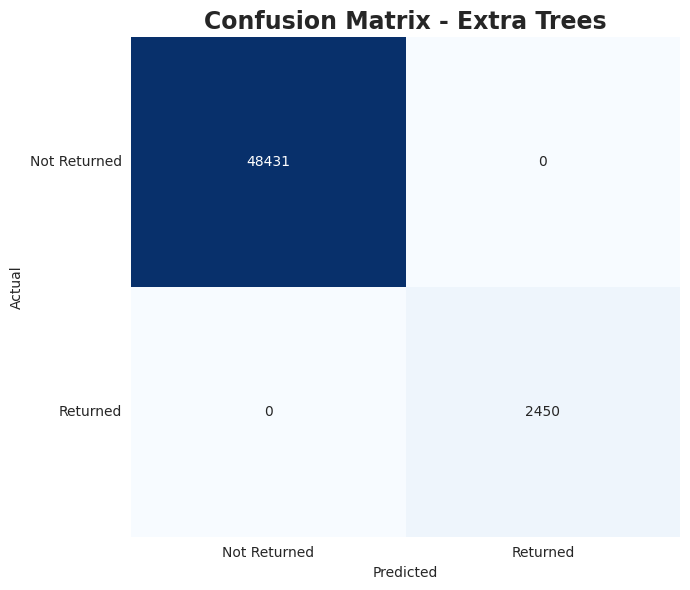

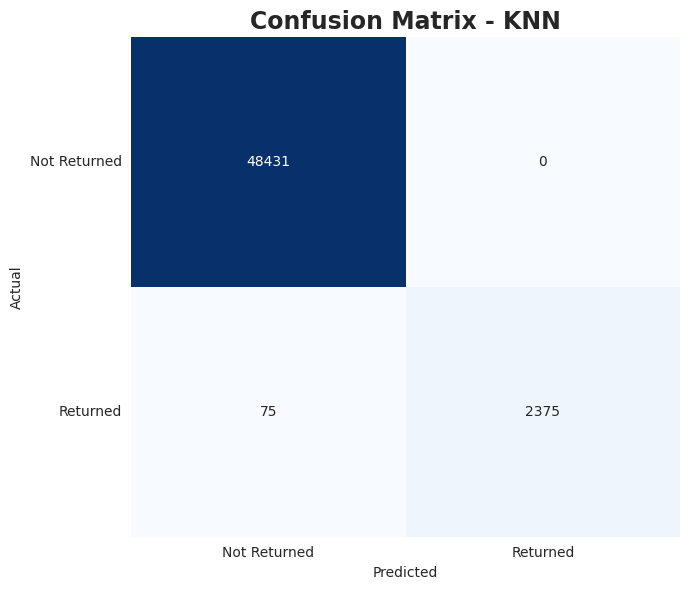

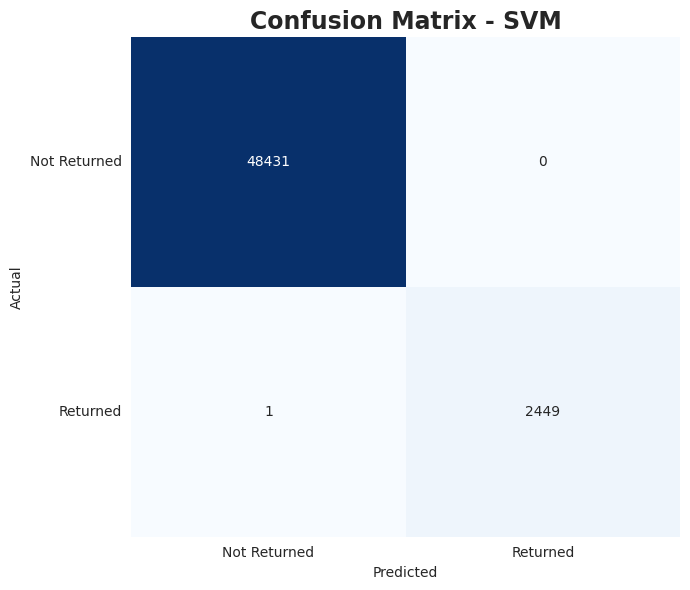

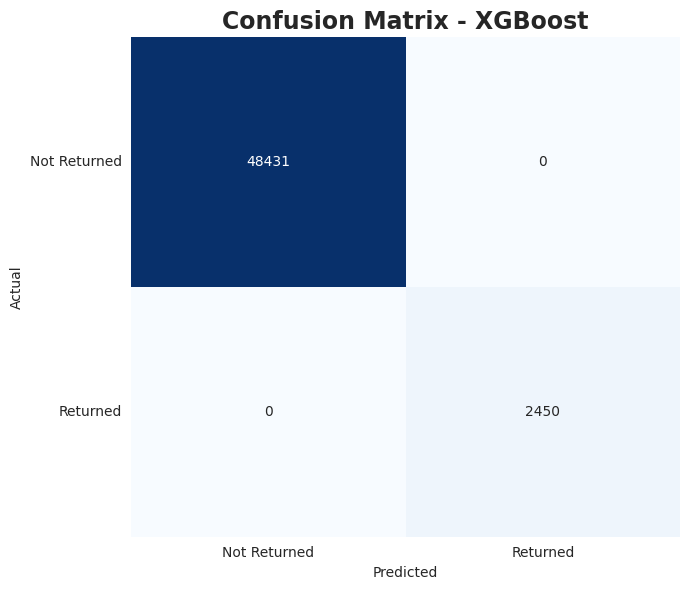


BEST MODEL
Best Model: Decision Tree
Best Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

Not Returned       1.00      1.00      1.00     48431
    Returned       1.00      1.00      1.00      2450

    accuracy                           1.00     50881
   macro avg       1.00      1.00      1.00     50881
weighted avg       1.00      1.00      1.00     50881



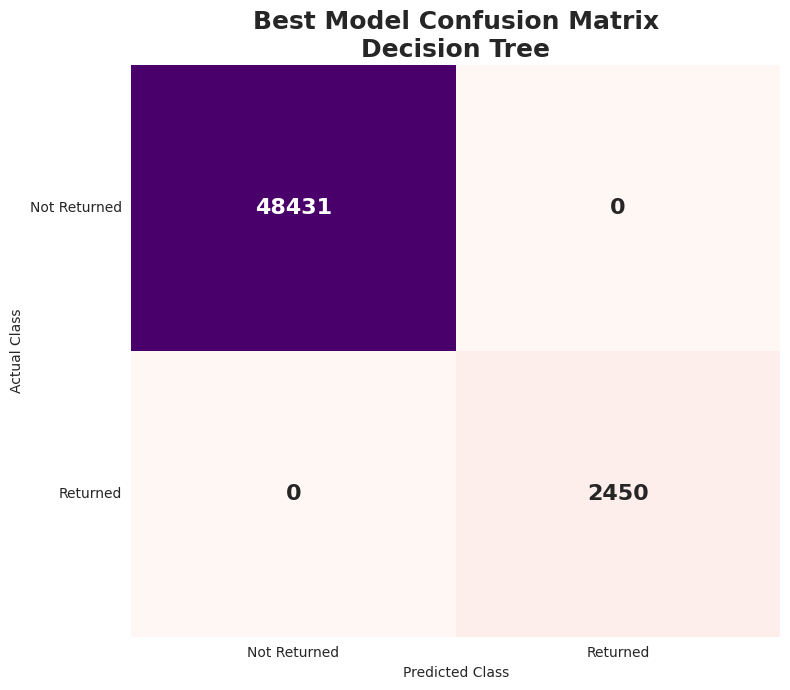


TOP 20 IMPORTANT FEATURES


,Feature,Importance
53,return_status,1.0
1,unit_price,0.0
0,quantity,0.0
3,item_revenue,0.0
4,item_cost,0.0
5,profit,0.0
6,order_status,0.0
7,shipping_method,0.0
8,delivery_city,0.0
9,delivery_state,0.0


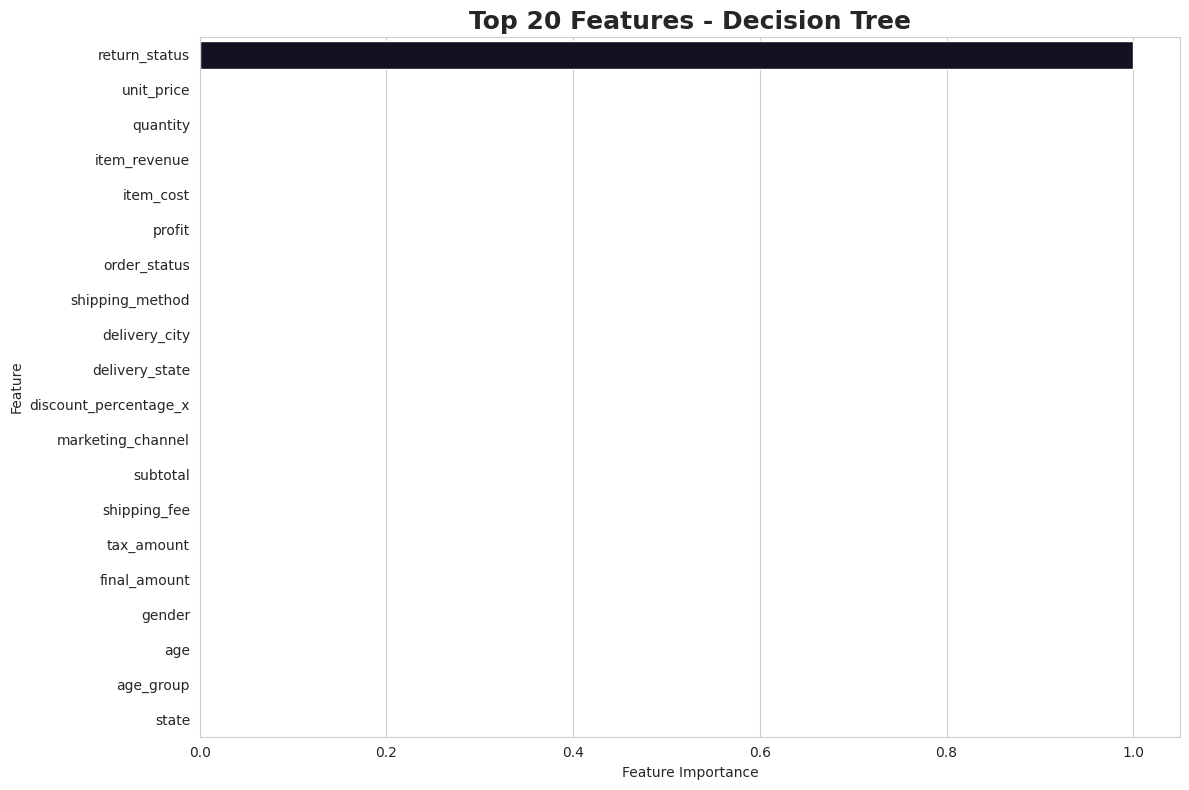


FINAL ACCURACY RESULTS
Decision Tree             : 100.00%
Random Forest             : 100.00%
Gradient Boosting         : 100.00%
Extra Trees               : 100.00%
XGBoost                   : 100.00%
SVM                       : 100.00%
Logistic Regression       : 100.00%
KNN                       : 99.85%

BEST MODEL
Decision Tree achieved 100.00% accuracy.


In [15]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost is not installed. XGBoost will be skipped.")


# ==============================================================
# 2. COPY DATASET
# ==============================================================

data = df.copy()

print("=" * 70)
print("ORIGINAL DATASET")
print("=" * 70)

print("Shape:", data.shape)

display(data.head())


# ==============================================================
# 3. REMOVE DUPLICATE ROWS
# ==============================================================

print("\nDuplicate rows:", data.duplicated().sum())

data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)


# ==============================================================
# 4. TARGET VARIABLE
# ==============================================================

target = "is_returned"

if target not in data.columns:
    raise ValueError(
        f"Target column '{target}' is not present in the dataset."
    )

print("\nTarget column:", target)


# ==============================================================
# 5. TARGET CLEANING
# ==============================================================

print("\nOriginal target values:")

print(data[target].value_counts(dropna=False))


# Convert common text values into 0/1 if required
if data[target].dtype == "object":

    target_mapping = {
        "yes": 1,
        "no": 0,
        "returned": 1,
        "not returned": 0,
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0
    }

    data[target] = (
        data[target]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(target_mapping)
    )


# Convert target to numeric
data[target] = pd.to_numeric(
    data[target],
    errors="coerce"
)

# Remove missing target rows
data = data.dropna(subset=[target])

# Convert target to integer
data[target] = data[target].astype(int)

print("\nCleaned target values:")
print(data[target].value_counts())

print("\nTarget classes:")
print(data[target].unique())


# ==============================================================
# 6. CHECK TARGET BALANCE
# ==============================================================

plt.figure(figsize=(8, 6))

sns.countplot(
    x=data[target],
    hue=data[target],
    palette=["#3498DB", "#E74C3C"],
    legend=False
)

plt.title(
    "Target Variable Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Is Returned")
plt.ylabel("Number of Records")

plt.xticks(
    [0, 1],
    ["Not Returned", "Returned"]
)

plt.tight_layout()
plt.show()


# ==============================================================
# 7. REMOVE ID COLUMNS
# ==============================================================

# IDs usually identify records rather than provide useful
# predictive information.

id_columns = [
    "order_item_id",
    "order_id",
    "product_id",
    "customer_id",
    "payment_id",
    "shipment_id",
    "return_id",
    "customer_id_ret",
    "campaign_id"
]

id_columns_to_drop = [
    col for col in id_columns
    if col in data.columns
]

data = data.drop(
    columns=id_columns_to_drop,
    errors="ignore"
)

print("\nRemoved ID columns:")
print(id_columns_to_drop)


# ==============================================================
# 8. REMOVE DUPLICATE / REDUNDANT COLUMNS
# ==============================================================

# These columns contain similar information from different
# merged tables.

redundant_columns = [
    "discount_percentage_y",
    "customer_id_ret",
    "delivery_city_ship",
    "shipping_method_ship",
    "refund_amount_ret"
]

redundant_columns = [
    col for col in redundant_columns
    if col in data.columns
]

data = data.drop(
    columns=redundant_columns,
    errors="ignore"
)

print("\nRemoved redundant columns:")
print(redundant_columns)


# ==============================================================
# 9. CONVERT DATE COLUMNS INTO USEFUL FEATURES
# ==============================================================

date_columns = [
    "order_date",
    "customer_signup_date",
    "last_order_date",
    "product_launch_date",
    "payment_date",
    "dispatch_date",
    "expected_delivery_date",
    "actual_delivery_date",
    "return_date"
]

for col in date_columns:

    if col in data.columns:

        data[col] = pd.to_datetime(
            data[col],
            errors="coerce"
        )

        # Year
        data[col + "_year"] = data[col].dt.year

        # Month
        data[col + "_month"] = data[col].dt.month

        # Day
        data[col + "_day"] = data[col].dt.day

        # Day of week
        data[col + "_dayofweek"] = data[col].dt.dayofweek


# ==============================================================
# 10. ORDER TIME FEATURE
# ==============================================================

if "order_time" in data.columns:

    try:

        time_values = pd.to_datetime(
            data["order_time"].astype(str),
            errors="coerce"
        )

        data["order_hour"] = time_values.dt.hour

    except:

        print("Could not convert order_time.")


# ==============================================================
# 11. REMOVE ORIGINAL DATE COLUMNS
# ==============================================================

data = data.drop(
    columns=[
        col for col in date_columns
        if col in data.columns
    ],
    errors="ignore"
)


# ==============================================================
# 12. REMOVE ORIGINAL TIME COLUMN
# ==============================================================

data = data.drop(
    columns=["order_time"],
    errors="ignore"
)


# ==============================================================
# 13. CHECK DATA
# ==============================================================

print("\n" + "=" * 70)
print("DATA AFTER PREPROCESSING")
print("=" * 70)

print("Shape:", data.shape)

display(data.head())


# ==============================================================
# 14. HANDLE BOOLEAN COLUMNS
# ==============================================================

boolean_columns = data.select_dtypes(
    include=["bool"]
).columns

for col in boolean_columns:
    data[col] = data[col].astype(int)


# ==============================================================
# 15. SEPARATE FEATURES AND TARGET
# ==============================================================

X = data.drop(
    columns=[target]
)

y = data[target]

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


# ==============================================================
# 16. REMOVE CONSTANT COLUMNS
# ==============================================================

constant_columns = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

print("\nConstant columns:")
print(constant_columns)

X = X.drop(
    columns=constant_columns
)


# ==============================================================
# 17. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ==============================================================

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ==============================================================
# 18. HANDLE MISSING VALUES
# ==============================================================

# Numerical columns -> median
for col in numeric_features:

    X[col] = X[col].fillna(
        X[col].median()
    )


# Categorical columns -> mode
for col in categorical_features:

    if X[col].mode().empty:
        X[col] = X[col].fillna("Unknown")

    else:
        X[col] = X[col].fillna(
            X[col].mode()[0]
        )


# ==============================================================
# 19. LABEL ENCODING
# ==============================================================

print("\n" + "=" * 70)
print("LABEL ENCODING")
print("=" * 70)

label_encoders = {}

for col in categorical_features:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = le

    print(
        f"{col}: {len(le.classes_)} categories encoded"
    )


# ==============================================================
# 20. CHECK FINAL DATA
# ==============================================================

print("\nFinal X shape:", X.shape)

print("\nFinal feature data types:")

print(X.dtypes)

print("\nMissing values remaining:")

print(X.isnull().sum().sum())


# ==============================================================
# 21. TRAIN TEST SPLIT
# ==============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ==============================================================
# 22. STANDARD SCALING
# ==============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\nScaling completed.")


# ==============================================================
# 23. DEFINE ML MODELS
# ==============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42,
            max_depth=10
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            max_depth=15
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}


# ==============================================================
# 24. ADD XGBOOST IF AVAILABLE
# ==============================================================

if xgb_available:

    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )


# ==============================================================
# 25. TRAIN ALL MODELS
# ==============================================================

results = []

trained_models = {}

print("\n" + "=" * 70)
print("MODEL TRAINING")
print("=" * 70)

for name, model in models.items():

    print(f"\nTraining: {name}")

    # Tree models can use original values,
    # while scaled data works well for most models.
    if name in [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees",
        "XGBoost"
    ]:

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        probabilities = model.predict_proba(
            X_test
        )[:, 1]

    else:

        model.fit(
            X_train_scaled,
            y_train
        )

        predictions = model.predict(
            X_test_scaled
        )

        probabilities = model.predict_proba(
            X_test_scaled
        )[:, 1]


    # Metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )


    # Save results
    results.append({

        "Model": name,

        "Accuracy": accuracy * 100,

        "Precision": precision * 100,

        "Recall": recall * 100,

        "F1 Score": f1 * 100,

        "ROC-AUC": auc

    })

    trained_models[name] = model

    print(
        f"{name} Accuracy: {accuracy * 100:.2f}%"
    )


# ==============================================================
# 26. MODEL COMPARISON TABLE
# ==============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(
    results_df.style.format({
        "Accuracy": "{:.2f}%",
        "Precision": "{:.2f}%",
        "Recall": "{:.2f}%",
        "F1 Score": "{:.2f}%",
        "ROC-AUC": "{:.4f}"
    })
)


# ==============================================================
# 27. ACCURACY COMPARISON GRAPH
# ==============================================================

plt.figure(figsize=(13, 7))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=19,
    fontweight="bold"
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Model")

plt.xlim(
    max(0, results_df["Accuracy"].min() - 10),
    100
)

for index, value in enumerate(
    results_df["Accuracy"]
):

    plt.text(
        value + 0.2,
        index,
        f"{value:.2f}%",
        va="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ==============================================================
# 28. PRECISION COMPARISON
# ==============================================================

plt.figure(figsize=(13, 7))

sns.barplot(
    data=results_df,
    x="Precision",
    y="Model",
    hue="Model",
    palette="plasma",
    legend=False
)

plt.title(
    "Precision Comparison",
    fontsize=19,
    fontweight="bold"
)

plt.xlabel("Precision (%)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ==============================================================
# 29. RECALL COMPARISON
# ==============================================================

plt.figure(figsize=(13, 7))

sns.barplot(
    data=results_df,
    x="Recall",
    y="Model",
    hue="Model",
    palette="magma",
    legend=False
)

plt.title(
    "Recall Comparison",
    fontsize=19,
    fontweight="bold"
)

plt.xlabel("Recall (%)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ==============================================================
# 30. F1 SCORE COMPARISON
# ==============================================================

plt.figure(figsize=(13, 7))

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model",
    hue="Model",
    palette="cool",
    legend=False
)

plt.title(
    "F1 Score Comparison",
    fontsize=19,
    fontweight="bold"
)

plt.xlabel("F1 Score (%)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ==============================================================
# 31. CONFUSION MATRIX FOR EACH MODEL
# ==============================================================

print("\n" + "=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)

for name, model in trained_models.items():

    if name in [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees",
        "XGBoost"
    ]:

        predictions = model.predict(
            X_test
        )

    else:

        predictions = model.predict(
            X_test_scaled
        )


    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(
        f"Confusion Matrix - {name}",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        [0.5, 1.5],
        ["Not Returned", "Returned"]
    )

    plt.yticks(
        [0.5, 1.5],
        ["Not Returned", "Returned"],
        rotation=0
    )

    plt.tight_layout()
    plt.show()


# ==============================================================
# 32. CLASSIFICATION REPORT FOR BEST MODEL
# ==============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "Best Model:",
    best_model_name
)

print(
    "Best Accuracy:",
    f"{results_df.iloc[0]['Accuracy']:.2f}%"
)


if best_model_name in [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "Extra Trees",
    "XGBoost"
]:

    best_predictions = best_model.predict(
        X_test
    )

else:

    best_predictions = best_model.predict(
        X_test_scaled
    )


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Not Returned",
            "Returned"
        ],
        zero_division=0
    )
)


# ==============================================================
# 33. BEST MODEL CONFUSION MATRIX
# ==============================================================

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdPu",
    cbar=False,
    annot_kws={
        "fontsize": 16,
        "fontweight": "bold"
    }
)

plt.title(
    f"Best Model Confusion Matrix\n{best_model_name}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0.5, 1.5],
    ["Not Returned", "Returned"]
)

plt.yticks(
    [0.5, 1.5],
    ["Not Returned", "Returned"],
    rotation=0
)

plt.tight_layout()
plt.show()


# ==============================================================
# 34. FEATURE IMPORTANCE
# ==============================================================
# Available for tree-based models.

if best_model_name in [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "Extra Trees",
    "XGBoost"
]:

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance":
            best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    ).head(20)


    print("\n" + "=" * 70)
    print("TOP 20 IMPORTANT FEATURES")
    print("=" * 70)

    display(importance)


    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="rocket",
        legend=False
    )

    plt.title(
        f"Top 20 Features - {best_model_name}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


# ==============================================================
# 35. FINAL MODEL ACCURACY
# ==============================================================

print("\n" + "=" * 70)
print("FINAL ACCURACY RESULTS")
print("=" * 70)

for _, row in results_df.iterrows():

    print(
        f"{row['Model']:25s} : "
        f"{row['Accuracy']:.2f}%"
    )


print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    f"{best_model_name} "
    f"achieved {results_df.iloc[0]['Accuracy']:.2f}% accuracy."
)

## Thank you..pls upvote!!!!!!!!!!!